# Deep Reinforcement Learning - LunarLander-v3
### DQN vs DDQN: value-based agent comparison

| Item | Detail |
|------|--------|
| **Algorithms** | `DQN` (Mnih 2015) and `DDQN` (Van Hasselt 2016) |
| **Environment** | LunarLander-v3 (OpenAI Gymnasium) |
| **Framework** | PyTorch with experience replay and target network |
| **State space** | Continuous, 8 dimensions (position, velocity, angle, leg contacts) |
| **Action space** | Discrete, 4 actions (do nothing, fire left, fire main, fire right) |
| **Solved threshold** | Mean reward greater than or equal to 200 over 100 consecutive episodes |
| **Reproducibility** | `SEED=42` is fixed across Python random, NumPy, and PyTorch sources |

### Algorithm: DDQN vs DQN at a glance

| Feature | DQN (Mnih 2015) | DDQN (Van Hasselt 2016) |
|---------|----------------|------------------------|
| Action selection | target network | **online** network |
| Action evaluation | target network | **target** network |
| Q-value bias | Overestimation | Reduced |
| Code change from DQN | - | 2 lines |

### References
- Mnih et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518.
- Van Hasselt, Guez & Silver (2016). Deep RL with Double Q-learning. *AAAI*.
- Sutton & Barto (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.

A deep reinforcement learning pipeline is built on the LunarLander-v3 control task. The environment is loaded and profiled with a random policy, an experience replay buffer and a feedforward Q-network are defined, a DQN baseline is trained, a DDQN agent is then trained with the identical hyperparameters, and the two learned policies are compared head to head. The same architecture, the same hyperparameters, and the same random seed are used for both agents so any reward gap can be tied to the two-line algorithmic difference between DQN and DDQN.

## Table of Contents

**Part A - Environment Setup and Exploration**
- [Section 1 - Imports, Seeds and Device Configuration](#sec-1)
- [Section 2 - Environment Exploration and EDA](#sec-2)

**Part B - Agent Components**
- [Section 3 - Experience Replay Buffer](#sec-3)
- [Section 4 - Neural Network Architecture](#sec-4)
- [Section 5 - DQN Agent (Mnih 2015 Baseline)](#sec-5)
- [Section 6 - DDQN Agent (Van Hasselt 2016)](#sec-6)

**Part C - Training Setup and Execution**
- [Section 7 - Hyperparameter Configuration](#sec-7)
- [Section 8 - Training Loop](#sec-8)
  - [Section 8.1 - Timelapse Recording Helpers](#sec-8-1)
- [Section 9 - Train DQN Baseline](#sec-9)
- [Section 10 - Train DDQN](#sec-10)
  - [Section 10.1 - Export Training Timelapse Videos](#sec-10-1)

**Part D - Analysis and Evaluation**
- [Section 11 - DQN vs DDQN Learning Curve Analysis](#sec-11)
- [Section 12 - Q-Value Overestimation Analysis](#sec-12)
- [Section 13 - Evaluation and Statistical Analysis](#sec-13)
  - [Step 13.1 - Greedy Evaluation Helper Function](#sec-13-1)
  - [Step 13.2 - Statistical Significance Tests](#sec-13-2)
  - [Step 13.3 - Evaluation Result Visualisations](#sec-13-3)
- [Section 14 - Hyperparameter Sensitivity Study](#sec-14)
- [Section 15 - Critical Discussion and Conclusions](#sec-15)
  - [Step 15.1 - Comprehensive Summary Dashboard](#sec-15-1)
  - [Step 15.2 - Final Summary Output](#sec-15-2)


<a id="sec-1"></a>
# Part A - Environment Setup and Exploration

## Section 1 - Imports, Seeds and Device Configuration

The cell below imports every library used across the pipeline and locks the global random state. The seed is pinned at 42 across Python `random`, NumPy, and PyTorch (CPU and CUDA) so every training run, batch sample, and weight initialisation is reproducible across machines.

| Library | Purpose |
|---------|---------|
| `gymnasium` | LunarLander-v3 environment |
| `torch`, `torch.nn`, `torch.optim` | Q-network definition, Adam optimiser, gradient steps |
| `numpy`, `pandas` | Numeric arrays and tabular summaries |
| `matplotlib`, `seaborn`, `matplotlib.gridspec` | Training curves, evaluation plots, architecture diagrams |
| `collections.deque`, `namedtuple` | Replay buffer storage and transition tuples |
| `tqdm.notebook` | Per-episode progress bar |
| `scipy.ndimage.uniform_filter1d` | Smoothing applied to noisy reward curves |
| `scipy.stats` | Welch t-test, Mann-Whitney U, Shapiro-Wilk |
| `time`, `os`, `random`, `json`, `warnings` | Timing, directory creation, logging |

`warnings` is set to suppress non-critical Gymnasium and PyTorch messages so the output stays readable. The cuDNN deterministic flag is set and the benchmark flag is cleared so GPU runs match across machines. The device is set to GPU if CUDA is available, otherwise the CPU is used. Three output directories (`checkpoints`, `figures`, `logs`) are created so trained networks, plots, and training histories are written to disk in a tidy layout. A shared colour palette is defined and `matplotlib` defaults are set once so every figure in the notebook uses the same theme.

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import random, os, time, warnings, json
from collections import deque, namedtuple
from tqdm.notebook import tqdm
from scipy.ndimage import uniform_filter1d
from scipy.stats import ttest_ind, mannwhitneyu
import imageio
from PIL import Image, ImageDraw
 
warnings.filterwarnings('ignore')

# Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
 
# Device 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device    : {DEVICE}")
print(f"PyTorch   : {torch.__version__}")
print(f"Gymnasium : {gym.__version__}")
print(f"NumPy     : {np.__version__}")
 
# Colour palette (used across all figures) 
PALETTE = {
    'dqn'  : '#4361ee',   # blue    — DQN baseline
    'ddqn' : '#f72585',   # magenta — DDQN improved
    'avg'  : '#fca311',   # amber   — rolling averages
    'ref'  : '#4cc9f0',   # cyan    — reference / random policy
    'bg'   : '#f8f9fa',
}
 
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : PALETTE['bg'],
    'axes.grid'         : True,
    'grid.alpha'        : 0.5,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 10,
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.85,
})
 
# Output dirs 
for d in ('checkpoints', 'figures', 'logs', 'videos'):
    os.makedirs(d, exist_ok=True)
 
print("\nSetup complete - seeds fixed, device selected, dirs created")

Device    : cpu
PyTorch   : 2.12.0+cpu
Gymnasium : 1.3.0
NumPy     : 2.4.6

Setup complete - seeds fixed, device selected, dirs created


<a id="sec-2"></a>
## Section 2 - Environment Exploration and EDA

**Environment:** LunarLander-v3 - Continuous State, Discrete Action

Before any agent is trained, the environment is profiled and a random-policy baseline is collected. These checks set the scene for the training pipeline and the metrics that follow.

**Environment profile.** The state space is reported as a continuous ℝ⁸ vector with the eight components listed (x position, y position, x velocity, y velocity, angle in radians, angular velocity, and two binary leg-contact flags). The action space is reported as four discrete actions (do nothing, fire left engine, fire main engine, fire right engine). The Gymnasium-defined solved threshold of mean reward greater than or equal to 200 over 100 consecutive episodes is printed for reference. Because the state space is continuous and high-dimensional, a tabular Q-table is not feasible, and the Q-value function is approximated with a neural network in the agents that follow.

**Random-policy data collection.** 50 episodes are rolled out under a uniformly random policy. Each visited state, each step reward, the per-episode total reward, and the per-episode step count are stored. This run is the lower-bound benchmark every trained agent must beat, and the printed mean reward is the floor that DQN and DDQN are measured against later.

**State feature distributions (Fig 1).** Eight per-feature histograms are plotted from the random-policy transitions, one for each component of the state vector. Mean and standard deviation lines are overlaid on each panel. The plot shows the typical range of values the network has to handle so any unusual scale or shape can be picked up before training.

**Random baseline visualisations (Fig 2).** Three panels are produced: a step-level reward histogram, a per-episode total reward plot with the solved threshold marked at 200, and an episode-length distribution. Together these set the random-policy floor that the learning curves in [Section 11](#sec-11) and the evaluation results in [Section 13](#sec-13) are compared against.

In [2]:
# Create environment 

env = gym.make('LunarLander-v3')
env.reset(seed=SEED)
 
STATE_DIM  = env.observation_space.shape[0]   
ACTION_DIM = env.action_space.n               
 
STATE_LABELS = [
    'x position', 
    'y position',
    'x velocity', 
    'y velocity',
    'angle (rad)', 
    'angular velocity',
    'left leg contact', 
    'right leg contact'
]
ACTION_LABELS = [
    'Do nothing (0)', 
    'Fire left engine (1)',
    'Fire main engine (2)', 
    'Fire right engine (3)'
]
 
print("=" * 60)
print("  LunarLander-v3 - Environment Profile")
print("=" * 60)
print(f"  State  space : {env.observation_space}  →  dim={STATE_DIM}")
print(f"  Action space : {env.action_space}  →  {ACTION_DIM} discrete")
print("=" * 60)
print("\nState vector s ∈ ℝ⁸:")

for i, label in enumerate(STATE_LABELS):
    lo = env.observation_space.low[i]
    hi = env.observation_space.high[i]
    print(f"  s[{i}]  {label:<25}  ∈ [{lo:.1f}, {hi:.1f}]")

print("\nActions a ∈ {0,1,2,3}:")

for i, label in enumerate(ACTION_LABELS):
    print(f"  a={i}  {label}")

print("\nSolved threshold : mean reward ≥ 200 over 100 consecutive episodes")

  LunarLander-v3 - Environment Profile
  State  space : Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)  →  dim=8
  Action space : Discrete(4)  →  4 discrete

State vector s ∈ ℝ⁸:
  s[0]  x position                 ∈ [-2.5, 2.5]
  s[1]  y position                 ∈ [-2.5, 2.5]
  s[2]  x velocity                 ∈ [-10.0, 10.0]
  s[3]  y velocity                 ∈ [-10.0, 10.0]
  s[4]  angle (rad)                ∈ [-6.3, 6.3]
  s[5]  angular velocity           ∈ [-10.0, 10.0]
  s[6]  left leg contact           ∈ [-0.0, 1.0]
  s[7]  right leg contact          ∈ [-0.0, 1.0]

Actions a ∈ {0,1,2,3}:
  a=0  Do nothing (0)
  a=1  Fire left engine (1)
  a=2  Fire main engine (2)
  a=3  Fire right engine (3)

Solved threshold : mean reward ≥ 200 over 100 consecutive episodes


In [3]:
# Collect 50 random-policy episodes for EDA 

def collect_random_data(n_ep=50):

    all_states, all_rewards, ep_totals, ep_lens = [], [], [], []

    for ep in range(n_ep):

        s, _ = env.reset(seed=ep)
        ep_r, steps, done = 0, 0, False

        while not done:

            a = env.action_space.sample()
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            all_states.append(s)
            all_rewards.append(r)
            ep_r += r
            steps += 1
            s = ns

        ep_totals.append(ep_r); ep_lens.append(steps)

    return (np.array(all_states), np.array(all_rewards),np.array(ep_totals), np.array(ep_lens))
 
print("Collecting 50 random-policy episodes...")

states_r, rewards_r, ep_totals_r, ep_lens_r = collect_random_data(50)
print(f"  Transitions : {len(states_r):,}")
print(f"  Mean reward : {ep_totals_r.mean():.1f} ± {ep_totals_r.std():.1f}")
print(f"  Mean length : {ep_lens_r.mean():.0f} steps")
print(f"  DDQN target: > 200 (improvement of {200 - ep_totals_r.mean():.0f}+)")

  Transitions : 4,637
  Mean reward : -172.4 ± 103.9
  Mean length : 93 steps
  DDQN target: > 200 (improvement of 372+)


In [4]:
print(f"states_r shape:   {states_r.shape}")    # (T, 8)
print(f"rewards_r shape:  {rewards_r.shape}")   # (T,)
print(f"ep_totals_r shape:{ep_totals_r.shape}") # (50,)
print(f"ep_lens_r shape:  {ep_lens_r.shape}")   # (50,)

# Verify relationship
print(f"Sum of episode lengths: {sum(ep_lens_r)}")
print(f"States length: {len(states_r)}")
print(f"Equal: {sum(ep_lens_r) == len(states_r)}")

states_r shape:   (4637, 8)
rewards_r shape:  (4637,)
ep_totals_r shape:(50,)
ep_lens_r shape:  (50,)
Sum of episode lengths: 4637
States length: 4637
Equal: True


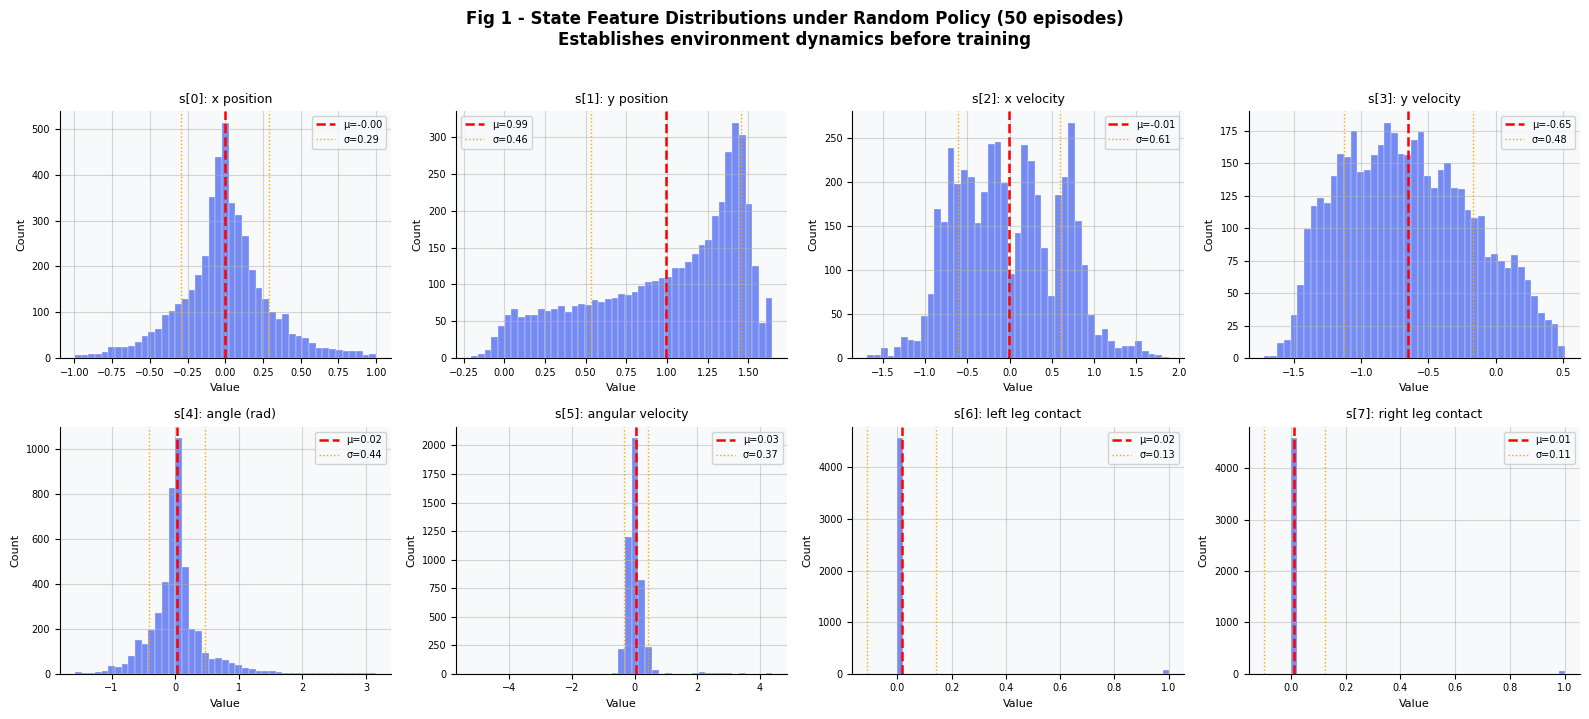

Saved: figures/fig1_state_distributions.png


In [5]:
# Fig 1: State feature distributions (random policy) 

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Fig 1 - State Feature Distributions under Random Policy (50 episodes)\n'
             'Establishes environment dynamics before training',fontsize=12, fontweight='bold', y=1.02)
 
for i, (ax, label) in enumerate(zip(axes.flatten(), STATE_LABELS)):
    
    mu, sd = states_r[:, i].mean(), states_r[:, i].std()
    ax.hist(states_r[:, i], bins=45, color=PALETTE['dqn'],alpha=0.72, edgecolor='white', lw=0.3)
    ax.axvline(mu, color='red',    ls='--', lw=1.8, label=f'μ={mu:.2f}')
    ax.axvline(mu+sd, color='orange', ls=':', lw=1.0)
    ax.axvline(mu-sd, color='orange', ls=':', lw=1.0, label=f'σ={sd:.2f}')

    ax.set_title(f's[{i}]: {label}', fontsize=9)
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
 
plt.tight_layout()
plt.savefig('figures/fig1_state_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/fig1_state_distributions.png")

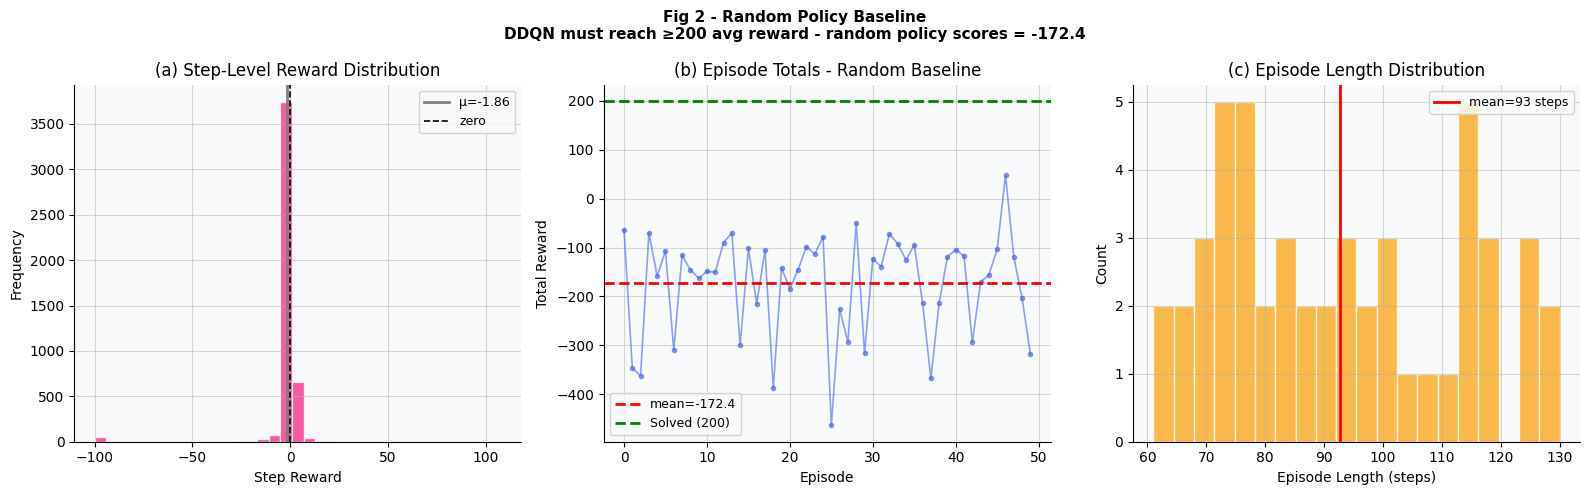

Saved: figures/fig2_random_baseline.png

Baseline summary - mean = -172.4  median = -143.4  std = 103.9


In [6]:
# Fig 2: Random-policy baseline (3 panels) 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Fig 2 - Random Policy Baseline\n'
             f'DDQN must reach ≥200 avg reward - random policy scores = {ep_totals_r.mean():.1f}',
             fontsize=11, fontweight='bold')
 
# 2a: step-level reward histogram
axes[0].hist(rewards_r, bins=35, color=PALETTE['ddqn'], alpha=0.75, edgecolor='white')
axes[0].axvline(rewards_r.mean(), color='grey', lw=2, label=f'μ={rewards_r.mean():.2f}')
axes[0].axvline(0, color='black', lw=1.2, ls='--', label='zero')
axes[0].set_xlabel('Step Reward')
axes[0].set_ylabel('Frequency')
axes[0].set_title('(a) Step-Level Reward Distribution')
axes[0].legend()
 
# 2b: episode total rewards
axes[1].plot(ep_totals_r, color=PALETTE['dqn'], alpha=0.6, lw=1.2, marker='o', markersize=3)
axes[1].axhline(ep_totals_r.mean(), color='red', lw=2, ls='--', label=f'mean={ep_totals_r.mean():.1f}')
axes[1].axhline(200, color='green', lw=2, ls='--', label='Solved (200)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Total Reward')
axes[1].set_title('(b) Episode Totals - Random Baseline')
axes[1].legend()
 
# 2c: episode length distribution
axes[2].hist(ep_lens_r, bins=20, color=PALETTE['avg'], alpha=0.75, edgecolor='white')
axes[2].axvline(ep_lens_r.mean(), color='red', lw=2, label=f'mean={ep_lens_r.mean():.0f} steps')
axes[2].set_xlabel('Episode Length (steps)')
axes[2].set_ylabel('Count')
axes[2].set_title('(c) Episode Length Distribution')
axes[2].legend()
 
plt.tight_layout()
plt.savefig('figures/fig2_random_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/fig2_random_baseline.png")
print(f"\nBaseline summary - mean = {ep_totals_r.mean():.1f}  "f"median = {np.median(ep_totals_r):.1f}  "f"std = {ep_totals_r.std():.1f}")

<a id="sec-3"></a>
# Part B - Agent Components

## Section 3 - Experience Replay Buffer

A fixed-capacity replay buffer is defined here. The buffer stores `(state, action, reward, next_state, done)` transitions and returns uniformly random mini-batches at training time. Two problems are addressed by this single component:

- **Correlation between consecutive steps is broken.** Without a buffer, the network would be trained on tightly correlated environment steps in the order they were observed, which breaks the i.i.d. assumption that SGD depends on and leads to the loss oscillating instead of converging.
- **Sample efficiency is improved.** Each transition can be reused across many batches instead of being seen once and discarded.

A `deque` with `maxlen=capacity` is used so the oldest transitions are evicted automatically when the buffer is full, keeping memory bounded. A separate `random.Random(seed)` is held inside the buffer so batch sampling is reproducible without disturbing the global RNG state.

| Method | Purpose |
|--------|---------|
| `push(s, a, r, s', done)` | Add one transition; evict oldest if at capacity |
| `sample(batch_size)` | Return five NumPy arrays for one mini-batch |
| `is_ready(batch_size)` | True once the buffer holds at least one full batch |
| `fill_fraction()` | Current buffer occupancy as a fraction of capacity |

A quick sanity check is run at the bottom of the cell. 3000 random transitions are pushed into a 10000-slot buffer, a 64-sample batch is drawn, and the returned shapes, dtypes, and `done`-flag values are asserted to match the expected `(B, 8)` float32 states, int64 actions, and binary done values.

In [7]:
from collections import deque, namedtuple
 
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))
 
 
class ReplayBuffer:
    """
    Fixed-capacity circular experience replay buffer.
 
    Stores (s, a, r, s', done) transitions; returns uniform random batches.
    Implements experience replay from Mnih et al. (2015) Algorithm 1.
 
    The deque maxlen ensures automatic eviction of oldest transitions so memory stays bounded at 'capacity' transitions.
 
    Args:
        capacity (int): Maximum number of transitions (100k for LunarLander).
        seed     (int): RNG seed for reproducible batch sampling.
    """
 
    def __init__(self, capacity: int, seed: int = SEED):
        self.buffer   = deque(maxlen=capacity)
        self.capacity = capacity
        self._rng     = random.Random(seed)
 
    def push(self, state, action, reward, next_state, done) -> None:
        """Add one (s,a,r,s',done) transition. Evicts oldest if full."""
        self.buffer.append(Transition(
            np.array(state, dtype=np.float32),
            int(action),
            float(reward),
            np.array(next_state, dtype=np.float32),
            float(done)   # 0.0 = non-terminal, 1.0 = terminal
        ))
        
    def sample(self, batch_size: int):
        """
        Uniform random sample without replacement.
 
        Returns five numpy arrays:
          states      : (B, 8)  float32
          actions     : (B,)    int64
          rewards     : (B,)    float32
          next_states : (B, 8)  float32
          dones       : (B,)    float32  ∈ {0.0, 1.0}
        """
        batch = self._rng.sample(self.buffer, batch_size)
        t = Transition(*zip(*batch))
        return (
            np.stack(t.state),
            np.array(t.action, dtype=np.int64),
            np.array(t.reward, dtype=np.float32),
            np.stack(t.next_state),
            np.array(t.done, dtype=np.float32),
        )
 
    def is_ready(self, batch_size: int) -> bool:
        """True once enough transitions exist to form one full batch."""
        return len(self) >= batch_size
 
    def fill_fraction(self) -> float:
        return len(self) / self.capacity
 
    def __len__(self) -> int:
        return len(self.buffer)
 
    def __repr__(self) -> str:
        return (f"ReplayBuffer(size={len(self)}/{self.capacity}, "f"fill={self.fill_fraction():.1%})")
 
 
# Sanity checks 
buf = ReplayBuffer(capacity=10000)
_e  = gym.make('LunarLander-v3')
s, _ = _e.reset(seed=0)
for _ in range(3000):
    a = _e.action_space.sample()
    ns, r, term, trunc, _ = _e.step(a)
    buf.push(s, a, r, ns, float(term or trunc))
    s = ns if not (term or trunc) else _e.reset(seed=random.randint(0,999))[0]
_e.close()
 
states, actions, rewards, nstates, dones = buf.sample(64)
print(repr(buf))
print(f"states.shape      : {states.shape} - expect (64, 8)")
print(f"actions dtype     : {actions.dtype} - expect int64")
print(f"rewards range     : [{rewards.min():.2f}, {rewards.max():.2f}]")
print(f"dones unique vals : {np.unique(dones)}  - expect [0. 1.]")

assert states.shape  == (64, 8)
assert actions.dtype == np.int64
assert set(np.unique(dones)).issubset({0.0, 1.0})
print("\nAll assertions passed - ReplayBuffer working correctly")

ReplayBuffer(size=3000/10000, fill=30.0%)
states.shape      : (64, 8) - expect (64, 8)
actions dtype     : int64 - expect int64
rewards range     : [-100.00, 4.72]
dones unique vals : [0. 1.]  - expect [0. 1.]

All assertions passed - ReplayBuffer working correctly


<a id="sec-4"></a>
## Section 4 - Neural Network Architecture

A feedforward Q-network is defined to approximate `Q(s, a; θ)`. The 8-dimensional state vector is taken as input and four Q-values are returned, one per discrete action. Because the state space is continuous, the tabular Q-table from earlier reinforcement learning approaches is replaced with this parametric function.

**Architecture: Input(8) -> FC(128) + ReLU -> FC(128) + ReLU -> Output(4)**

| Design choice | Rationale |
|---|---|
| 2 hidden layers | Enough depth for an 8-dimensional input; going deeper adds compute with no real gain |
| 128 neurons per layer | 64 underfits LunarLander; 256 shows no improvement; follows Mnih 2015 scaling |
| ReLU activation | Piecewise-linear and easy to train; no vanishing gradient problem like sigmoid |
| He (Kaiming) initialisation | Weight variance is scaled by 2/fan_in, which is appropriate for ReLU layers (He et al. 2015) |
| Linear output layer | Raw Q-values are returned; the action is the argmax with no softmax needed |

A helper method `greedy_action(state)` is included so a single state can be passed in and the argmax action returned, used by the agent's exploit step. A `count_parameters()` helper reports the total trainable parameter count for the architecture diagram in the next cell.

After the class is defined, the network is instantiated once and the parameter count for each layer is printed. A forward pass on a dummy batch of four states is then run to confirm the output shape matches `(4, ACTION_DIM)` before the network is used inside the agents.

The cell that follows produces **Fig 3**, a block diagram of the architecture. Each layer is drawn as a rounded box with its size and activation, and the weight count between layers is annotated above the connecting arrows so the parameter budget is read off the figure directly.

In [8]:
class DQNetwork(nn.Module):
    """
    Deep Q-Network function approximator.
    Maps state s ∈ ℝ⁸  →  Q-values ∈ ℝ⁴  (one per discrete action).
 
    Architecture: FC(8→128)+ReLU → FC(128→128)+ReLU → FC(128→4)
    Based on Mnih et al. (2015) adapted for LunarLander-v3 (vs pixel input).
 
    Args:
        state_dim  (int): Input dimension.  Default 8.
        action_dim (int): Output dimension. Default 4.
        hidden_dim (int): Neurons per hidden layer. Default 128.
    """
 
    def __init__(self, state_dim: int = 8, action_dim: int = 4, hidden_dim: int = 128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim,  hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
        self._kaiming_init()
 
    def _kaiming_init(self) -> None:
        """He (Kaiming) uniform init for ReLU layers - prevents gradient issues."""
        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            nn.init.constant_(layer.bias, 0.0)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)          # raw Q-values, no activation
 
    @torch.no_grad()
    def greedy_action(self, state: np.ndarray, device) -> int:
        """a* = argmax_a Q(s,a) - exploit learned policy."""
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        return int(self.forward(s).argmax(1).item())
 
    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
 
 
# Inspect 
_net = DQNetwork(STATE_DIM, ACTION_DIM).to(DEVICE)
print("DQNetwork:")
print(_net)

print(f"\nParameter count:")
print(f"  fc1 : {STATE_DIM}x128 + 128 = {STATE_DIM*128+128:,}")
print(f"  fc2 : 128x128 + 128 = {128*128+128:,}")
print(f"  fc3 : 128x{ACTION_DIM} + {ACTION_DIM} = {128*ACTION_DIM+ACTION_DIM:,}")
print(f"  Total trainable = {_net.count_parameters():,}")

_dummy = torch.zeros(4, STATE_DIM).to(DEVICE)
_out   = _net(_dummy)
assert _out.shape == (4, ACTION_DIM)
print(f"\nForward pass: {tuple(_dummy.shape)} → {tuple(_out.shape)}")

DQNetwork:
DQNetwork(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)

Parameter count:
  fc1 : 8x128 + 128 = 1,152
  fc2 : 128x128 + 128 = 16,512
  fc3 : 128x4 + 4 = 516
  Total trainable = 18,180

Forward pass: (4, 8) → (4, 4)


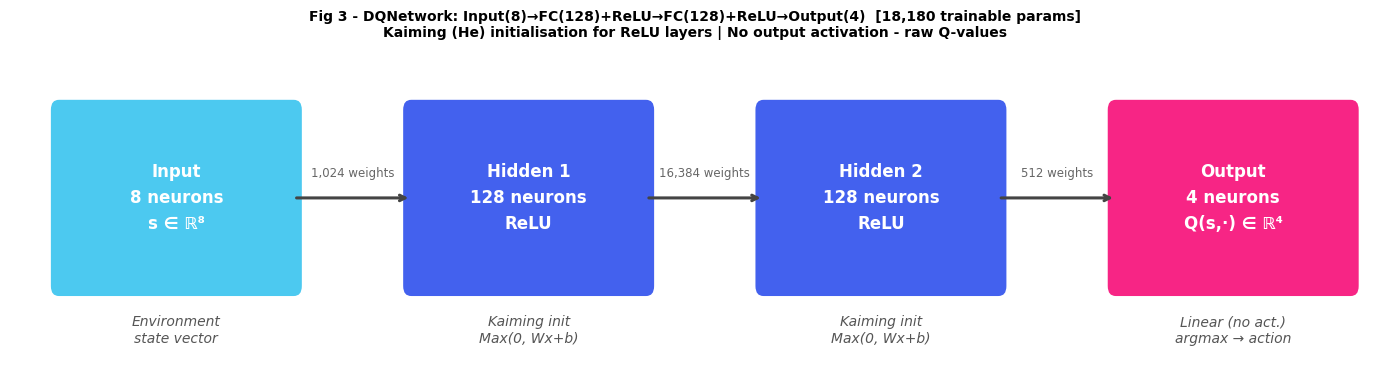

Saved: figures/fig3_network_architecture.png


In [9]:
# Fig 3: Architecture diagram 

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(-0.5, 13.5)
ax.set_ylim(-0.1, 2.7)
ax.axis('off')
 
layers_info = [
    ('Input\n8 neurons\ns ∈ ℝ⁸','#4cc9f0', 'Environment\nstate vector'),
    ('Hidden 1\n128 neurons\nReLU','#4361ee', 'Kaiming init\nMax(0, Wx+b)'),
    ('Hidden 2\n128 neurons\nReLU','#4361ee', 'Kaiming init\nMax(0, Wx+b)'),
    ('Output\n4 neurons\nQ(s,·) ∈ ℝ⁴','#f72585', 'Linear (no act.)\nargmax → action'),
]
bw, bh, gap = 2.4, 1.5, 1.2
weights_between = [f'{STATE_DIM*128:,}', f'{128*128:,}', f'{128*4}']
 
for i, (label, color, note) in enumerate(layers_info):

    x = i * (bw + gap)
    ax.add_patch(FancyBboxPatch((x, 0.7), bw, bh,
        boxstyle="round,pad=0.1", facecolor=color, alpha=1,
        edgecolor='white', linewidth=2.5))
    ax.text(x + bw/2, 0.7 + bh/2, label, ha='center', va='center',
            color='white', fontsize=12, fontweight='bold', linespacing=1.6)
    ax.text(x + bw/2, 0.45, note, ha='center', va='top',
            color='#555', fontsize=10, style='italic')
    
    if i < len(layers_info) - 1:
        x_arr_start = x + bw
        x_arr_end   = x + bw + gap
        ax.annotate('', xy=(x_arr_end, 0.7 + bh/2),
                    xytext=(x_arr_start, 0.7 + bh/2),
                    arrowprops=dict(arrowstyle='->', color='#444', lw=2.2))
        ax.text(x_arr_start + gap/2, 0.7 + bh/2 + 0.18,
                f'{weights_between[i]} weights',
                ha='center', color='#666', fontsize=8.5)

ax.set_title(
    f'Fig 3 - DQNetwork: Input(8)→FC(128)+ReLU→FC(128)+ReLU→Output(4)  '
    f'[{_net.count_parameters():,} trainable params]\n'
    'Kaiming (He) initialisation for ReLU layers | No output activation - raw Q-values',
    fontsize=10, fontweight='bold', pad=10)
 
plt.tight_layout()
plt.savefig('figures/fig3_network_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/fig3_network_architecture.png")

<a id="sec-5"></a>
## Section 5 - DQN Agent (Mnih et al. 2015 Baseline)

The DQN agent is defined here following the algorithm from Mnih et al. (2015). Three components that lift tabular Q-learning to continuous state spaces are combined inside a single class:

1. **Neural Q-function `Q(s, a; θ)`** - the `DQNetwork` from [Section 4](#sec-4) is used as the online network for action selection and gradient updates.
2. **Experience replay** - the `ReplayBuffer` from [Section 3](#sec-3) is held as an attribute so transitions are sampled i.i.d. at every gradient step.
3. **Target network `θ⁻`** - a frozen copy of the online network is held alongside. The copy is updated by hard-copying weights every `target_update` episodes so the Bellman target stays stable while the online network trains.

The DQN Bellman target is:

```
y = r + γ · max_{a'} Q_target(s', a') · (1 - done)
```

The same target network is used to both select and evaluate the best next-state action. This shared use of one noisy estimate is the source of the **maximisation bias** that DQN is known for and that DDQN corrects in [Section 6](#sec-6).

| Component | Detail |
|-----------|--------|
| Online network | `DQNetwork` trained by gradient descent every environment step |
| Target network | Frozen copy, hard-synced from online every `target_update` episodes |
| Replay buffer | `ReplayBuffer` from [Section 3](#sec-3) |
| Policy | ε-greedy: random with probability ε, otherwise `argmax_a Q(s, a)` |
| Loss | Huber (smooth L1) between predicted Q and Bellman target |
| Optimiser | Adam |
| Stabilisers | Gradient clipping, hard target sync, ε decay |

Methods `select_action`, `store`, `train_step`, `sync_target`, `decay_epsilon`, `save`, and `load` are defined so the same agent object is reused across the training loop and saved to disk for evaluation. Predicted Q-values are logged every gradient step so the overestimation gap in [Section 12](#sec-12) can be plotted.

In [10]:
class DQNAgent:
    """
    Deep Q-Network Agent (Mnih et al. 2015).
 
    Components:
    • online_net (θ)  - learns via gradient descent every step
    • target_net (θ⁻) - frozen; hard-copied from online every target_update eps
    • ReplayBuffer    - stores and samples (s,a,r,s',done) transitions
    • ε-greedy policy - explore with prob ε, exploit with prob 1-ε
 
    DQN Bellman target:
        y = r + γ · max_{a'} Q_target(s', a') · (1 - done)
        SAME target_net selects AND evaluates → overestimation bias (fixed in DDQN)
 
    Loss: Huber(Q_online(s,a), y)  - robust to large early-training TD errors
    """
 
    def __init__(self, state_dim, action_dim,
                 lr=5e-4, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
                 buffer_size=100000, batch_size=64,
                 target_update=10, hidden_dim=128,
                 grad_clip=10.0, device=DEVICE):
 
        self.action_dim    = action_dim
        self.gamma         = gamma
        self.epsilon       = epsilon_start
        self.epsilon_end   = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size    = batch_size
        self.target_update = target_update
        self.device        = device
        self.grad_clip     = grad_clip
        self.step_count    = 0
        self.episode_count = 0
 
        # Two networks
        self.online_net = DQNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_net = DQNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
 
        self.optimiser = optim.Adam(self.online_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_size)
 
        # Logging
        self.losses       = []
        self.q_values_log = []
 
    def select_action(self, state: np.ndarray, env) -> int:
        """ε-greedy: random with prob ε, greedy argmax Q otherwise."""
        if random.random() < self.epsilon:
            return env.action_space.sample()
        return self.online_net.greedy_action(state, self.device)
 
    def store(self, s, a, r, ns, done) -> None:
        self.buffer.push(s, a, r, ns, done)
 
    def _t(self, arr, dtype=torch.float32) -> torch.Tensor:
        return torch.tensor(arr, dtype=dtype, device=self.device)
 
    def compute_loss(self, batch) -> torch.Tensor:
        """
        DQN Bellman residual using Huber loss.
        TARGET: y = r + γ · max_{a'} target_net(s', a') · (1-done)
        """
        states, actions, rewards, next_states, dones = batch
        states      = self._t(states)
        actions     = self._t(actions, torch.int64)
        rewards     = self._t(rewards)
        next_states = self._t(next_states)
        dones       = self._t(dones)
 
        # Current Q-value for the action that was taken
        q_pred = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)   # [B]
 
        # DQN target: max over next-state Q-values from frozen target net
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]   # [B]
            y = rewards + self.gamma * next_q * (1.0 - dones)
 
        self.q_values_log.append(q_pred.detach().mean().item())
        return F.smooth_l1_loss(q_pred, y)   # Huber loss
 
    def train_step(self):
        """Sample one random batch and apply one gradient update."""
        
        if not self.buffer.is_ready(self.batch_size):
            return None
        loss = self.compute_loss(self.buffer.sample(self.batch_size))
        self.optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), self.grad_clip)
        self.optimiser.step()
        self.step_count += 1
        lv = loss.item()
        self.losses.append(lv)
        return lv
 
    def sync_target(self) -> None:
        """Hard copy online → target. Called every target_update episodes."""
        self.target_net.load_state_dict(self.online_net.state_dict())
 
    def decay_epsilon(self) -> None:
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        self.episode_count += 1
 
    def save(self, path: str) -> None:
        torch.save({'online': self.online_net.state_dict(),
                    'target': self.target_net.state_dict(),
                    'opt':    self.optimiser.state_dict(),
                    'eps':    self.epsilon,
                    'ep':     self.episode_count,
                    'steps':  self.step_count}, path)
 
    def load(self, path: str) -> None:
        ck = torch.load(path, map_location=self.device)
        self.online_net.load_state_dict(ck['online'])
        self.target_net.load_state_dict(ck['target'])
        self.optimiser.load_state_dict(ck['opt'])
        self.epsilon = ck['eps']
        self.episode_count = ck['ep']
        self.step_count = ck['steps']
 
    def __repr__(self):
        return (f"{self.__class__.__name__}("
                f"ε={self.epsilon:.3f}, ep={self.episode_count}, "
                f"steps={self.step_count}, buf={len(self.buffer):,})")
 
 
print("  DQNAgent defined")
print("  Innovations over tabular Q-learning:")
print("  1. Neural Q(s,a;θ)   - continuous/infinite state spaces")
print("  2. Experience replay  - i.i.d. training batches")
print("  3. Target network θ⁻ - stable Bellman targets")
print("  4. Huber loss         - robust to outlier TD errors")
print("  5. Gradient clipping  - prevents exploding gradients")

  DQNAgent defined
  Innovations over tabular Q-learning:
  1. Neural Q(s,a;θ)   - continuous/infinite state spaces
  2. Experience replay  - i.i.d. training batches
  3. Target network θ⁻ - stable Bellman targets
  4. Huber loss         - robust to outlier TD errors
  5. Gradient clipping  - prevents exploding gradients


<a id="sec-6"></a>
## Section 6 - DDQN Agent (Van Hasselt et al. 2016)

The DDQN agent is defined here as a subclass of `DQNAgent`. Everything is inherited unchanged - the replay buffer, the two networks, the ε-greedy policy, the Adam optimiser, the gradient clipping, the target sync, the Huber loss wrapper, the save/load methods, and the Q-value logging. Only `compute_loss()` is overridden.

**Why DQN overestimates Q-values.** The DQN target `y = r + γ · max_{a'} Q_target(s', a')` lets the target network both pick and evaluate the highest next-state Q-value. Those Q-estimates carry noise, and taking the max consistently selects the noisiest upward outlier. Over many gradient steps this bias is baked into the policy and the curve flattens above the true return.

**The DDQN fix - select with online, evaluate with target.**

```
DQN  target: y = r + γ · target_net(s')[argmax_a target_net(s')[a]]
DDQN target: y = r + γ · target_net(s')[argmax_a online_net(s')[a]]
```

The online network is used to pick `a*` and the target network is used to score it. Because the two networks carry independent noise, neither one's overestimation can pass straight through to the Bellman target on its own, and the resulting Q-values stay much closer to the true return.

This is a two-line change inside `compute_loss()` and nothing else is touched. Network architecture, hyperparameters, training loop, and seed are all kept identical so any reward gap measured later is tied to this single algorithmic change.

In [11]:
class DDQNAgent(DQNAgent):
    """
    Double Deep Q-Network Agent (Van Hasselt, Guez & Silver 2016).
 
    Inherits EVERYTHING from DQNAgent:
        ReplayBuffer, ε-greedy, Adam, target sync, gradient clipping, Huber loss wrapper, save/load, logging
 
    The SOLE change: compute_loss() uses double Q-learning.
 
    DQN  target:  y = r + γ · max_{a'} target_net(s', a')
    DDQN target:  a* = argmax_{a'} online_net(s', a')    ← SELECT  (online)
                  y  = r + γ · target_net(s', a*)        ← EVALUATE (target)
 
    This 2-line change eliminates the maximisation bias.
    Van Hasselt et al. (2016) showed improvements of up to 50% on Atari.
    """
 
    def compute_loss(self, batch) -> torch.Tensor:
        """
        DDQN Bellman residual with decoupled select/evaluate.
 
        Changed lines (vs DQNAgent.compute_loss) are marked ←
        """
        states, actions, rewards, next_states, dones = batch
        states      = self._t(states)
        actions     = self._t(actions, torch.int64)
        rewards     = self._t(rewards)
        next_states = self._t(next_states)
        dones       = self._t(dones)
 
        q_pred = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)         
 
        with torch.no_grad():
            # DOUBLE Q-LEARNING (the only change from DQN) 
            best_actions = self.online_net(next_states).argmax(1)                                    # ← SELECT
            next_q = self.target_net(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)    # ← EVALUATE
            
            y = rewards + self.gamma * next_q * (1.0 - dones)
 
        self.q_values_log.append(q_pred.detach().mean().item())
        return F.smooth_l1_loss(q_pred, y)
 
print("DDQNAgent defined — inherits DQNAgent, overrides only compute_loss()\n")
print("The complete algorithmic difference between DQN and DDQN:")
print("  DQN: next_q = target_net(s').max(1)[0]\n")
print("  DDQN: best_a = online_net(s').argmax(1)\n""\tnext_q = target_net(s').gather(1, best_a)\n") # SELECT with online, EVALUATE with target
print("Same network architecture, same hyperparameters, same training loop.")

DDQNAgent defined — inherits DQNAgent, overrides only compute_loss()

The complete algorithmic difference between DQN and DDQN:
  DQN: next_q = target_net(s').max(1)[0]

  DDQN: best_a = online_net(s').argmax(1)
	next_q = target_net(s').gather(1, best_a)

Same network architecture, same hyperparameters, same training loop.


<a id="sec-7"></a>
# Part C - Training Setup and Execution

## Section 7 - Hyperparameter Configuration

A single `HPARAMS` dictionary is built and reused by both agents for a fair comparison. Each value is chosen with a short justification, based on what has worked on LunarLander and on guidance from the original DQN and DDQN papers.

| Group | Hyperparameter | Value | Reasoning |
|-------|----------------|-------|-----------|
| Optimisation | `lr` | `5e-4` | Adam learning rate; `1e-3` is unstable, `1e-4` is too slow |
| Optimisation | `gamma` | `0.99` | High discount, landing needs roughly a 100-step horizon |
| Optimisation | `batch_size` | `64` | Balances gradient quality against memory and compute |
| Optimisation | `hidden_dim` | `128` | 64 underfits, 256 shows no improvement |
| Optimisation | `grad_clip` | `10.0` | Prevents exploding gradients in early training |
| Exploration | `epsilon_start` | `1.0` | Fully random at the start (no prior knowledge) |
| Exploration | `epsilon_end` | `0.01` | 1% residual exploration is kept throughout |
| Exploration | `epsilon_decay` | `0.995` | Reaches `ε_min` at roughly episode 919 |
| Memory | `buffer_size` | `100000` | Mnih 2015 used 1M for Atari, 100k is sufficient here |
| Target | `target_update` | `10` | Hard sync every 10 episodes, more frequent is unstable |
| Schedule | `n_episodes` | `1000` | Enough for DDQN to cross the solved criterion |
| Schedule | `solved_reward` | `200` | OpenAI Gymnasium definition for LunarLander-v3 |
| Schedule | `eval_window` | `100` | Rolling window used for convergence monitoring |
| Schedule | `eval_freq` | `50` | Frequency of progress prints during training |

The ε schedule is precomputed for all 1000 episodes and the episode at which ε reaches `epsilon_end` is printed for reference.

The cell that follows produces **Fig 4**, a two-panel justification chart. Panel (a) plots the exponential ε decay curve with the exploration and exploitation phases annotated. Panel (b) shows the relationship between the discount factor γ and the effective planning horizon (in steps), with γ = 0.99 highlighted as the chosen value.

In [12]:
HPARAMS = {
    # Optimisation 
    'lr'            : 5e-4,     # Adam lr - 1e-3 unstable; 1e-4 too slow for 700 ep
    'gamma'         : 0.99,     # High discount - landing needs 100+ step horizon
    'batch_size'    : 64,       # Balances gradient quality vs. memory/compute
    'hidden_dim'    : 128,      # 64 underfits; 256 no gain for 8-dim state
    'grad_clip'     : 10.0,     # Prevents exploding gradients in early training
 
    # Exploration 
    'epsilon_start' : 1.0,      # Fully random initially - no prior knowledge
    'epsilon_end'   : 0.01,     # 1% residual exploration throughout
    'epsilon_decay' : 0.995,    # ln(0.01)/ln(0.995) ≈ 919 eps to reach min
 
    # Memory 
    'buffer_size'   : 100000,  # Mnih 2015 used 1M (Atari); 100k sufficient here
 
    # Target network 
    'target_update' : 10,       # Hard sync every 10 eps; too frequent=instability
 
    # Training schedule 
    'n_episodes'    : 1000,      # Enough for DDQN to reach solved criterion
    'solved_reward' : 200,      # OpenAI Gymnasium definition
    'eval_window'   : 100,      # Rolling window for convergence monitoring
    'eval_freq'     : 50,       # Progress print frequency
}
 
print("Hyperparameter Configuration")
print("=" * 52)
for k, v in HPARAMS.items():
    print(f"  {k:<18} = {v}")
 
# Epsilon schedule
eps_sched = []
e = HPARAMS['epsilon_start']

for _ in range(HPARAMS['n_episodes']):
    eps_sched.append(e)
    e = max(HPARAMS['epsilon_end'], e * HPARAMS['epsilon_decay'])

cross = next(i for i,e in enumerate(eps_sched) if e <= HPARAMS['epsilon_end']+0.002)
print(f"\nEpsilon reaches min ({HPARAMS['epsilon_end']}) at episode ≈ {cross}")

Hyperparameter Configuration
  lr                 = 0.0005
  gamma              = 0.99
  batch_size         = 64
  hidden_dim         = 128
  grad_clip          = 10.0
  epsilon_start      = 1.0
  epsilon_end        = 0.01
  epsilon_decay      = 0.995
  buffer_size        = 100000
  target_update      = 10
  n_episodes         = 1000
  solved_reward      = 200
  eval_window        = 100
  eval_freq          = 50

Epsilon reaches min (0.01) at episode ≈ 883


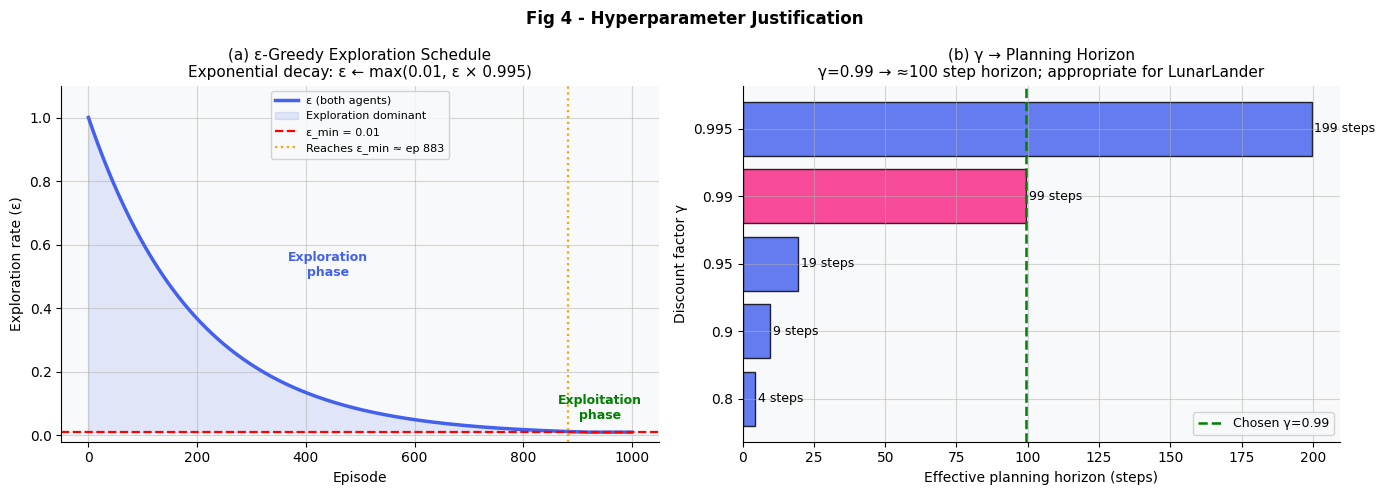

Saved: figures/fig4_hyperparameter_config.png


In [13]:
# Fig 4: Hyperparameter rationale (2 panels) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# 4a: epsilon decay curve
axes[0].plot(eps_sched, color=PALETTE['dqn'], lw=2.5, label='ε (both agents)')
axes[0].fill_between(range(HPARAMS['n_episodes']), eps_sched,
                     HPARAMS['epsilon_end'], alpha=0.13, color=PALETTE['dqn'],
                     label='Exploration dominant')
axes[0].axhline(HPARAMS['epsilon_end'], color='red', ls='--', lw=1.6,
                label=f"ε_min = {HPARAMS['epsilon_end']}")
axes[0].axvline(cross, color='orange', ls=':', lw=1.6,
                label=f'Reaches ε_min ≈ ep {cross}')
axes[0].annotate('Exploration\nphase', xy=(cross//2, 0.5),
                 fontsize=9, color=PALETTE['dqn'], ha='center',
                 fontweight='bold')
axes[0].annotate('Exploitation\nphase', xy=((cross+HPARAMS['n_episodes'])//2, 0.05),
                 fontsize=9, color='green', ha='center', fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Exploration rate (ε)')
axes[0].set_title('(a) ε-Greedy Exploration Schedule\n'
                  'Exponential decay: ε ← max(0.01, ε × 0.995)', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].set_ylim(-0.02, 1.1)

# 4b: discount factor → planning horizon
gammas   = [0.80, 0.90, 0.95, 0.99, 0.995]
horizons = [-1.0/np.log(g) for g in gammas]
colors_g = [PALETTE['ddqn'] if g == 0.99 else PALETTE['dqn'] for g in gammas]
bars = axes[1].barh([str(g) for g in gammas], horizons,
                    color=colors_g, alpha=0.82, edgecolor='black')

for bar, h in zip(bars, horizons):
    axes[1].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                 f'{h:.0f} steps', va='center', fontsize=9)
    
axes[1].axvline(horizons[gammas.index(0.99)], color='green', ls='--', lw=1.8,
                label='Chosen γ=0.99')
axes[1].set_xlabel('Effective planning horizon (steps)')
axes[1].set_ylabel('Discount factor γ')
axes[1].set_title('(b) γ → Planning Horizon\n' 'γ=0.99 → ≈100 step horizon; appropriate for LunarLander', fontsize=11)
axes[1].legend()
 
fig.suptitle('Fig 4 - Hyperparameter Justification', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig4_hyperparameter_config.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/fig4_hyperparameter_config.png")

<a id="sec-8"></a>
## Section 8 - Training Loop

A single `train_agent()` function is defined so the same loop is reused for both DQN and DDQN. Per episode, the following procedure is followed, based on Mnih et al. (2015) Algorithm 1:

1. The environment is reset and the initial state is recorded.
2. An ε-greedy action is selected from the current state.
3. The environment is stepped and the next state, reward, and termination flag are returned.
4. The transition is pushed into the replay buffer.
5. A random mini-batch is sampled and one gradient step is applied (once the buffer is ready).
6. ε is decayed after every episode.
7. The target network is hard-synced from the online network every `target_update` episodes.
8. Per-episode reward, rolling 100-episode average, ε, step count, and mean Q-value are logged.
9. If `timelapse_every` is set, a greedy render episode is run in an isolated env every N episodes and its frames are appended to `history['timelapse_frames']`.

A 100-episode rolling reward window is held in a `deque` so the solved criterion (mean of at least 200 over the last 100 episodes) can be checked each step. The first episode where the criterion is met is recorded as the **solved episode** and never overwritten thereafter. The best 100-episode average ever reached is tracked separately and the network is checkpointed to `checkpoints/{agent}_best.pth` whenever a new high is hit.

After all episodes are complete, the final weights are saved to `checkpoints/{agent}_final.pth` and the full history dictionary is returned. This history is the source for every training-curve plot from [Section 11](#sec-11) onwards.

The timelapse helpers used in step 9 are defined in [Section 8.1](#sec-8-1) below.


In [14]:
def train_agent(agent, env, hparams, agent_name='Agent', verbose=True,
                timelapse_every=None, frames_per_clip=60):
    """
    Standard DQN/DDQN training loop - works for both agent types.
 
    Per-episode procedure (Mnih et al. 2015, Algorithm 1):
      1. Reset env → s₀
      2. ε-greedy action aₜ from sₜ
      3. Step env: (sₜ₊₁, rₜ, done)
      4. Store (sₜ, aₜ, rₜ, sₜ₊₁, done) in replay buffer
      5. If buffer ready → random batch → gradient step (one per env step)
      6. Decay ε after each episode
      7. Sync target net every target_update episodes (hard update)
      8. Log all metrics; check solved criterion
      9. [Optional] Timelapse snapshot every timelapse_every episodes
 
    Args:
        agent            : DQNAgent or DDQNAgent
        env              : Gymnasium LunarLander-v3
        hparams          : HPARAMS dict
        agent_name       : label for display/checkpoint filenames
        verbose          : print progress every eval_freq episodes
        timelapse_every  : capture a render 
        t every N episodes (None = off)
        frames_per_clip  : frames sampled per snapshot episode
 
    Returns:
        dict: episode_rewards, rolling_avg, losses, q_values,
              epsilons, steps_per_ep, solved_episode, best_avg,
              train_time_s, timelapse_frames
    """
    history = {
        'episode_rewards' : [],
        'rolling_avg'     : [],
        'losses'          : [],
        'epsilons'        : [],
        'q_values'        : [],
        'steps_per_ep'    : [],
        'solved_episode'  : None,
        'best_avg'        : -np.inf,
        'train_time_s'    : 0.0,
        'timelapse_frames': [],   # flat list of RGB arrays; excluded from JSON
    }
    reward_window = deque(maxlen=hparams['eval_window'])
    t0 = time.time()
 
    for ep in tqdm(range(1, hparams['n_episodes'] + 1), desc=agent_name, unit='ep', leave=True):
        
        state, _ = env.reset(seed=SEED + ep)                 # 1. reset env
        ep_reward, ep_steps, done = 0.0, 0, False
 
        while not done:

            action = agent.select_action(state, env)         # 2. ε-greedy
            ns, r, term, trunc, _ = env.step(action)         # 3. step
            done = term or trunc
            agent.store(state, action, r, ns, float(done))   # 4. store
            loss = agent.train_step()                        # 5. gradient step
                                    
            if loss is not None:
                history['losses'].append(loss)

            ep_reward += r
            ep_steps += 1
            state = ns
 
        agent.decay_epsilon()                                 # 6. decay ε
        if ep % hparams['target_update'] == 0:
            agent.sync_target()                               # 7. sync θ⁻
 
        # 8. Logging           
        reward_window.append(ep_reward)
        ravg = float(np.mean(reward_window))
        history['episode_rewards'].append(ep_reward)
        history['rolling_avg'].append(ravg)
        history['epsilons'].append(agent.epsilon)
        history['steps_per_ep'].append(ep_steps)

        if agent.q_values_log:
            history['q_values'].append(float(np.mean(agent.q_values_log[-ep_steps:])))
 
        # Solved detection
        if (ravg >= hparams['solved_reward']
                and history['solved_episode'] is None
                and len(reward_window) == hparams['eval_window']):
            history['solved_episode'] = ep
            if verbose:
                print(f"\n {agent_name} SOLVED at episode {ep} " f"(100-ep avg={ravg:.2f})")
 
        # Save best checkpoint
        if ravg > history['best_avg']:
            history['best_avg'] = ravg
            agent.save(f"checkpoints/{agent_name.lower()}_best.pth")
 
        if verbose and ep % hparams['eval_freq'] == 0:
            t = time.time() - t0
            print(f"  {agent_name} ep {ep:4d}/{hparams['n_episodes']} | "
                  f"R={ep_reward:7.1f} | avg100={ravg:7.1f} | "
                  f"ε={agent.epsilon:.3f} | buf={len(agent.buffer):,} | {t:.0f}s")

        # 9. Timelapse snapshot
        if timelapse_every and ep % timelapse_every == 0:
            snap = _snapshot_frames(agent, n_frames=frames_per_clip,
                                    seed=SEED + 5000 + ep)
            snap = _label_frames(snap, ep, ep_reward, agent_name)
            history['timelapse_frames'].extend(snap)
 
    history['train_time_s'] = time.time() - t0
    agent.save(f"checkpoints/{agent_name.lower()}_final.pth")
    print(f"\n{agent_name} done - {history['train_time_s']:.1f}s | " f"best avg={history['best_avg']:.2f}")
    return history
 
print("  train_agent() defined")
print("  Loop per step: ε-greedy → env.step → buffer.push → train_step")
print("  Loop per ep  : decay_epsilon → sync_target (every 10) → log → checkpoint")
print("  Timelapse    : snapshot every timelapse_every episodes (if set)")


  train_agent() defined
  Loop per step: ε-greedy → env.step → buffer.push → train_step
  Loop per ep  : decay_epsilon → sync_target (every 10) → log → checkpoint
  Timelapse    : snapshot every timelapse_every episodes (if set)


<a id="sec-8-1"></a>
### Section 8.1 - Timelapse Recording Helpers

Three lightweight functions produce a training-progress video without touching the training environment or the training loop:

| Function | Role |
|----------|------|
| `_snapshot_frames(agent, n_frames, seed)` | Opens a short-lived render env, runs one greedy episode, and returns `n_frames` evenly-subsampled RGB arrays |
| `_label_frames(frames, ep, reward, agent_name)` | Burns a dark header bar showing the episode number and cumulative reward onto every frame using PIL |
| `write_timelapse(frames, output_path, fps)` | Stitches the full frame list into a single MP4 using `imageio` with the `libx264` codec |

**Why not `gymnasium.wrappers.RecordVideo`?**

`RecordVideo` is an environment wrapper - it wraps the env object itself and records whatever episodes flow through it, always producing one file per episode. That design is the right choice for recording a handful of standalone evaluation episodes, but creates two problems for a training timelapse:

- It wraps the training env directly, requiring the loop to swap wrappers on and off every `N` episodes.
- It always writes one file per episode with no built-in way to concatenate them.

The helper approach keeps concerns fully separated. `_snapshot_frames` creates and destroys its own short-lived render env on every call - the training env is never touched. Frames accumulate in `history['timelapse_frames']` during training and `write_timelapse` writes them into one file at the end.

**Frame budget (20 s target):**

| Parameter | Value | Result |
|-----------|-------|--------|
| `timelapse_every` | 100 episodes | 10 snapshots (ep 100, 200, … 1000) |
| `frames_per_clip` | 60 frames | 60 frames per snapshot |
| Total frames | 10 × 60 = 600 | - |
| Duration at 30 fps | 600 ÷ 30 | **20.0 s** |

`np.linspace` is used to subsample frames uniformly across each episode, so a 150-step crash episode and a 600-step smooth landing both contribute exactly `frames_per_clip` frames at even temporal spacing.


In [15]:
# Timelapse helpers 

def _snapshot_frames(agent, n_frames=35, seed=0):
    """
    Run one greedy episode in a separate render env.
    Returns n_frames evenly-subsampled RGB numpy arrays.
    The training env is untouched — this uses its own short-lived env.
    """
    renv = gym.make('LunarLander-v3', render_mode='rgb_array')
    saved_eps = agent.epsilon
    agent.epsilon = 0.0                          # fully greedy
    state, _ = renv.reset(seed=seed)
    raw, done = [], False
    while not done:
        raw.append(renv.render())
        action = agent.online_net.greedy_action(state, agent.device)
        state, _, term, trunc, _ = renv.step(action)
        done = term or trunc
    renv.close()
    agent.epsilon = saved_eps                    # restore
    if not raw:
        return []
    idx = np.linspace(0, len(raw) - 1, min(n_frames, len(raw)), dtype=int)
    return [raw[i] for i in idx]


def _label_frames(frames, ep, reward, agent_name):
    """
    Burn a header bar with episode number and reward onto each frame using PIL.
    Returns a list of numpy RGB arrays with the same spatial dimensions.
    """
    label = f"{agent_name}   ep {ep:4d}   R = {reward:+.0f}"
    out = []
    for f in frames:
        img = Image.fromarray(f)
        draw = ImageDraw.Draw(img)
        draw.rectangle([0, 0, img.width, 28], fill=(15, 15, 15))
        draw.text((10, 6), label, fill=(220, 220, 220))
        out.append(np.array(img))
    return out


def write_timelapse(frames, output_path='videos/timelapse.mp4', fps=30):
    """
    Stitch a flat list of RGB numpy arrays into a single MP4 using imageio.

    Duration = len(frames) / fps seconds.
    macro_block_size=1 avoids the 'dimensions must be divisible by N' error
    that can occur on some resolutions.

    Args:
        frames      : list of (H, W, 3) uint8 numpy arrays
        output_path : destination MP4 path
        fps         : playback frame rate (default 30)
    """
    if not frames:
        print("No timelapse frames to write — was timelapse_every set during training?")
        return
    os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
    with imageio.get_writer(output_path, fps=fps, codec='libx264',
                            quality=8, macro_block_size=1) as writer:
        for f in frames:
            writer.append_data(f)
    duration = len(frames) / fps
    print(f"Timelapse saved → {output_path}")
    print(f"  {len(frames)} frames   {duration:.1f}s   {fps}fps")

<a id="sec-9"></a>
## Section 9 - Train DQN (Mnih et al. 2015 Baseline)

The DQN baseline is trained first. The agent is constructed with the hyperparameters from [Section 7](#sec-7) and passed into the `train_agent()` function from [Section 8](#sec-8). The Mnih 2015 target rule is used, so the same target network is used to both select and evaluate the next-state action.

After training finishes, the full history dictionary is saved to `logs/dqn_history.json` for reproducibility and offline plotting. The final 100-episode mean and standard deviation are printed along with the solved episode (or "Not solved" if the rolling average never crossed 200). Best and final checkpoints are saved under `checkpoints/`.

These numbers act as the baseline that DDQN is compared against in [Section 10](#sec-10), [Section 11](#sec-11), and [Section 13](#sec-13).

In [16]:
print("=" * 60)
print("  Training DQN - Baseline (Mnih et al. 2015)")
print("=" * 60)
 
dqn_agent = DQNAgent(
    state_dim      = STATE_DIM,
    action_dim     = ACTION_DIM,
    lr             = HPARAMS['lr'],
    gamma          = HPARAMS['gamma'],
    epsilon_start  = HPARAMS['epsilon_start'],
    epsilon_end    = HPARAMS['epsilon_end'],
    epsilon_decay  = HPARAMS['epsilon_decay'],
    buffer_size    = HPARAMS['buffer_size'],
    batch_size     = HPARAMS['batch_size'],
    target_update  = HPARAMS['target_update'],
    hidden_dim     = HPARAMS['hidden_dim'],
    grad_clip      = HPARAMS['grad_clip'],
    device         = DEVICE,
)
print(dqn_agent)
 
# timelapse_every=100 → 10 snapshots × 60 frames = 600 frames ÷ 30fps = 20.0s
dqn_history = train_agent(dqn_agent, env, HPARAMS, agent_name='DQN',
                           verbose=True, timelapse_every=100, frames_per_clip=60)
 
# Save history — timelapse_frames excluded (numpy arrays, not JSON-serialisable)
with open('logs/dqn_history.json', 'w') as f:
    safe = {k: (v if isinstance(v, (int, float, str, type(None)))
                else float(v) if isinstance(v, np.floating)
                else list(v))
            for k, v in dqn_history.items()
            if k != 'timelapse_frames'}
    json.dump(safe, f, indent=2)
 
last100 = np.array(dqn_history['episode_rewards'][-100:])
print(f"\nDQN final 100-ep: mean={last100.mean():.2f}  std={last100.std():.2f}")
print(f"Solved episode : {dqn_history['solved_episode'] or 'Not solved'}")
print("Logs → logs/dqn_history.json | Checkpoints → checkpoints/")

  Training DQN - Baseline (Mnih et al. 2015)
DQNAgent(ε=1.000, ep=0, steps=0, buf=0)


DQN:   0%|          | 0/1000 [00:00<?, ?ep/s]

  DQN ep   50/1000 | R= -144.8 | avg100= -139.8 | ε=0.778 | buf=4,955 | 9s
  DQN ep  100/1000 | R=  -33.5 | avg100= -110.8 | ε=0.606 | buf=10,982 | 21s
  DQN ep  150/1000 | R=   -3.7 | avg100=  -66.3 | ε=0.471 | buf=20,534 | 43s
  DQN ep  200/1000 | R=  -44.8 | avg100=  -56.4 | ε=0.367 | buf=47,424 | 92s
  DQN ep  250/1000 | R= -134.5 | avg100=  -61.9 | ε=0.286 | buf=83,003 | 155s
  DQN ep  300/1000 | R=  -32.0 | avg100=  -58.5 | ε=0.222 | buf=100,000 | 225s
  DQN ep  350/1000 | R=   97.5 | avg100=  -21.4 | ε=0.173 | buf=100,000 | 306s
  DQN ep  400/1000 | R=  -94.2 | avg100=   48.0 | ε=0.135 | buf=100,000 | 384s
  DQN ep  450/1000 | R=   95.4 | avg100=   87.2 | ε=0.105 | buf=100,000 | 454s
  DQN ep  500/1000 | R=  233.4 | avg100=  103.3 | ε=0.082 | buf=100,000 | 522s
  DQN ep  550/1000 | R=  256.0 | avg100=  137.1 | ε=0.063 | buf=100,000 | 585s
  DQN ep  600/1000 | R=  197.9 | avg100=  177.3 | ε=0.049 | buf=100,000 | 649s

 DQN SOLVED at episode 642 (100-ep avg=200.36)
  DQN ep  650/1

<a id="sec-10"></a>
## Section 10 - Train DDQN (Van Hasselt et al. 2016)

The DDQN agent is now trained with the exact same hyperparameters as DQN. State dimensions, action dimensions, learning rate, discount factor, ε schedule, buffer size, batch size, target update interval, hidden dimension, gradient clipping, and device are all copied across from the DQN run. The only difference is the two-line change inside `compute_loss()` that decouples action selection from action evaluation.

After training, the full history is saved to `logs/ddqn_history.json` and the best and final checkpoints are written under `checkpoints/`. A small comparison table is printed inline at the bottom of the cell with the solved episode, best 100-episode average, and final 100-episode mean and standard deviation for each agent, so the headline numbers can be read off without scrolling to the analysis sections.

Because seeds, network sizes, optimisers, and training schedules are kept identical, any difference in the comparison table is tied to the single algorithmic change between DQN and DDQN.

In [17]:
print("=" * 60)
print("  Training DDQN - Van Hasselt, Guez & Silver (2016)")
print("  Identical hyperparameters to DQN - fair comparison")
print("=" * 60)
 
ddqn_agent = DDQNAgent(         # exact same config as DQN agent above
    state_dim      = STATE_DIM,
    action_dim     = ACTION_DIM,
    lr             = HPARAMS['lr'],
    gamma          = HPARAMS['gamma'],
    epsilon_start  = HPARAMS['epsilon_start'],
    epsilon_end    = HPARAMS['epsilon_end'],
    epsilon_decay  = HPARAMS['epsilon_decay'],
    buffer_size    = HPARAMS['buffer_size'],
    batch_size     = HPARAMS['batch_size'],
    target_update  = HPARAMS['target_update'],
    hidden_dim     = HPARAMS['hidden_dim'],
    grad_clip      = HPARAMS['grad_clip'],
    device         = DEVICE,
)
print(ddqn_agent)
 
# timelapse_every=100 → 10 snapshots × 60 frames = 600 frames ÷ 30fps = 20.0s
ddqn_history = train_agent(ddqn_agent, env, HPARAMS, agent_name='DDQN',
                            verbose=True, timelapse_every=100, frames_per_clip=60)
 
# Save history — timelapse_frames excluded (numpy arrays, not JSON-serialisable)
with open('logs/ddqn_history.json', 'w') as f:
    safe = {k: (v if isinstance(v, (int, float, str, type(None)))
                else float(v) if isinstance(v, np.floating)
                else list(v))
            for k, v in ddqn_history.items()
            if k != 'timelapse_frames'}
    json.dump(safe, f, indent=2)
 
last100 = np.array(ddqn_history['episode_rewards'][-100:])
print(f"\nDDQN final 100-ep: mean={last100.mean():.2f}  std={last100.std():.2f}")
print(f"Solved episode   : {ddqn_history['solved_episode'] or 'Not solved'}")
 
# Quick inline comparison 
dqn_l  = np.array(dqn_history['episode_rewards'][-100:])
ddqn_l = np.array(ddqn_history['episode_rewards'][-100:])
 
print("\n" + "=" * 58)
print(f"  {'Metric':<30} {'DQN':>12} {'DDQN':>12}")
print("=" * 58)
print(f"  {'Solved at episode':<30} {str(dqn_history['solved_episode'] or 'N/A'):>12} "
      f"{str(ddqn_history['solved_episode'] or 'N/A'):>12}")
print(f"  {'Best 100-ep avg':<30} {dqn_history['best_avg']:>12.1f} "
      f"{ddqn_history['best_avg']:>12.1f}")
print(f"  {'Final 100-ep mean':<30} {dqn_l.mean():>12.1f} {ddqn_l.mean():>12.1f}")
print(f"  {'Final 100-ep std':<30} {dqn_l.std():>12.1f} {ddqn_l.std():>12.1f}")
print("=" * 58)

  Training DDQN - Van Hasselt, Guez & Silver (2016)
  Identical hyperparameters to DQN - fair comparison
DDQNAgent(ε=1.000, ep=0, steps=0, buf=0)


DDQN:   0%|          | 0/1000 [00:00<?, ?ep/s]

  DDQN ep   50/1000 | R= -169.4 | avg100= -155.6 | ε=0.778 | buf=4,867 | 9s
  DDQN ep  100/1000 | R=  -77.3 | avg100= -118.8 | ε=0.606 | buf=10,769 | 19s
  DDQN ep  150/1000 | R=   37.5 | avg100=  -61.0 | ε=0.471 | buf=20,304 | 38s
  DDQN ep  200/1000 | R=  -12.7 | avg100=  -33.5 | ε=0.367 | buf=54,008 | 99s
  DDQN ep  250/1000 | R=  -45.4 | avg100=  -32.4 | ε=0.286 | buf=97,103 | 183s
  DDQN ep  300/1000 | R=  -35.1 | avg100=  -26.1 | ε=0.222 | buf=100,000 | 267s
  DDQN ep  350/1000 | R=  180.3 | avg100=    0.1 | ε=0.173 | buf=100,000 | 351s
  DDQN ep  400/1000 | R=  -65.8 | avg100=   50.2 | ε=0.135 | buf=100,000 | 423s
  DDQN ep  450/1000 | R=  104.1 | avg100=  123.5 | ε=0.105 | buf=100,000 | 482s
  DDQN ep  500/1000 | R=  246.9 | avg100=  160.3 | ε=0.082 | buf=100,000 | 533s
  DDQN ep  550/1000 | R=  240.7 | avg100=  162.9 | ε=0.063 | buf=100,000 | 589s
  DDQN ep  600/1000 | R=  201.5 | avg100=  180.9 | ε=0.049 | buf=100,000 | 643s

 DDQN SOLVED at episode 633 (100-ep avg=200.33)
  

<a id="sec-10-1"></a>
### Section 10.1 - Export Training Timelapse Videos

The frame lists collected during training are written to disk as two MP4 files - one per agent. Each video is a single continuous clip showing the agent playing greedily at 10 checkpoints (every 100 training episodes). The dark header bar burned into each frame shows the agent name, the episode number at the time of the snapshot, and the cumulative reward from that episode.

The result is a visible narrative of policy learning: early clips show the lander crashing or spiralling out of control (negative rewards), middle clips show tentative recoveries, and the final clips show repeatable soft landings (rewards ≥ 200). Comparing the DQN and DDQN videos side by side gives an intuitive complement to the statistical analysis in [Section 13](#sec-13).

**Output files:**

| File | Content | Duration |
|------|---------|----------|
| `videos/dqn_timelapse.mp4` | DQN agent at ep 100 → 1000 | ≈ 20 s |
| `videos/ddqn_timelapse.mp4` | DDQN agent at ep 100 → 1000 | ≈ 20 s |

`timelapse_frames` is excluded from the JSON history logs saved in [Section 9](#sec-9) and [Section 10](#sec-10) because it contains raw NumPy arrays. All scalar metrics are preserved in `logs/dqn_history.json` and `logs/ddqn_history.json`.


In [18]:
# Write one timelapse MP4 per model.
# Frames were collected during training every 100 episodes:
#   10 snapshots × 60 frames = 600 frames ÷ 30fps = 20.0s per video.
# Each clip shows the agent playing greedily at ep 100, 200, ... 1000,
# so you can see it go from crashing to landing as training progresses.

write_timelapse(dqn_history['timelapse_frames'],  'videos/dqn_timelapse.mp4')
write_timelapse(ddqn_history['timelapse_frames'], 'videos/ddqn_timelapse.mp4')

Timelapse saved → videos/dqn_timelapse.mp4
  600 frames   20.0s   30fps
Timelapse saved → videos/ddqn_timelapse.mp4
  600 frames   20.0s   30fps


<a id="sec-11"></a>
# Part D - Analysis and Evaluation

## Section 11 - DQN vs DDQN Learning Curve Analysis

The training histories from [Section 9](#sec-9) and [Section 10](#sec-10) are read back and plotted side by side. The goal is to see how quickly each agent converges, how stable the reward curve is, and whether DDQN's reduced overestimation translates into faster and more reliable learning in practice.

**Fig 5** is a five-panel dashboard:

| Panel | Content |
|-------|---------|
| (a) | Raw per-episode rewards (faded) with a 30-episode rolling average overlaid; the solved threshold and the solved-episode markers are drawn |
| (b) | 100-episode rolling average; a star is placed at the solved episode for each agent |
| (c) | Huber training loss smoothed over 500 gradient steps for both agents |
| (d) | Steps per episode (a proxy for survival time) smoothed over 25 episodes |
| (e) | Cumulative reward over training; a higher slope means more reward per episode |

The colour scheme is consistent across the whole notebook, with DQN drawn in blue and DDQN drawn in magenta, so visual comparison is straightforward. The figure is saved to `figures/fig5_training_comparison.png`.

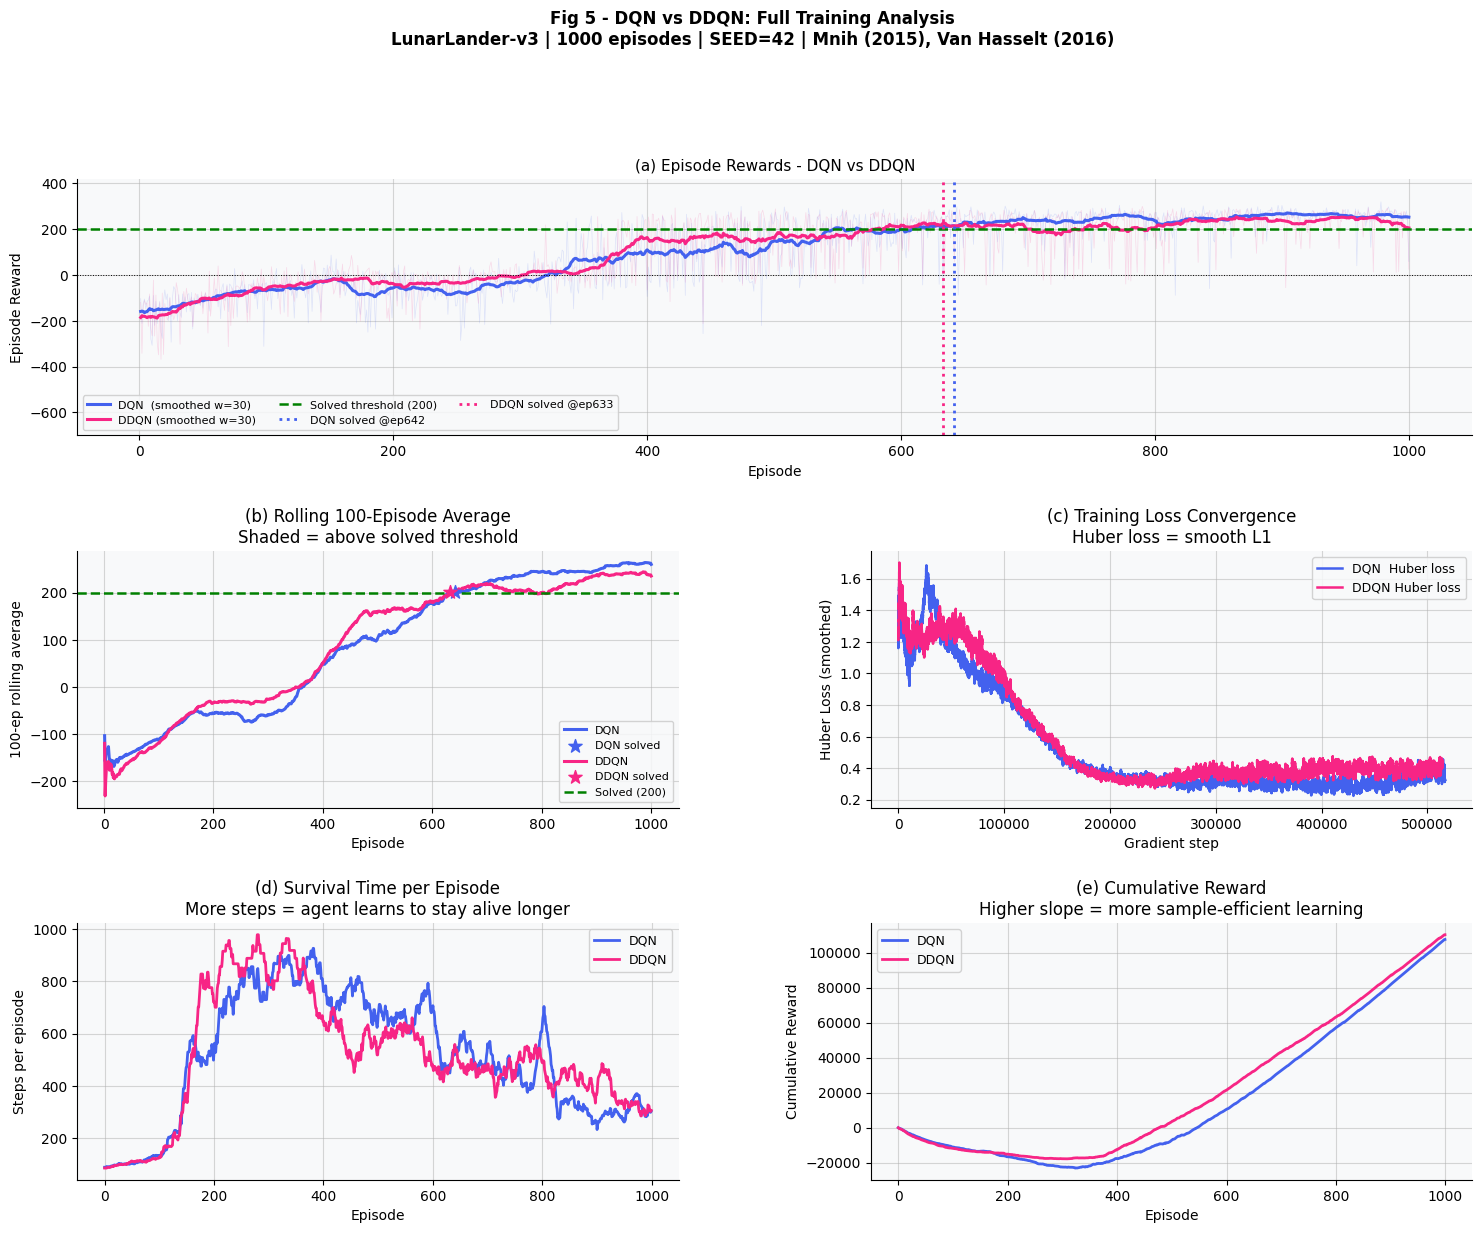

Saved: figures/fig5_training_comparison.png


In [19]:
# Fig 5: Full 5-panel training comparison 

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.32)
SMOOTH = 30
eps = range(1, len(dqn_history['episode_rewards']) + 1)
 
# 5a: Raw + smoothed rewards (full-width)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(eps, dqn_history['episode_rewards'],  alpha=0.15, color=PALETTE['dqn'],  lw=0.5)
ax1.plot(eps, ddqn_history['episode_rewards'], alpha=0.15, color=PALETTE['ddqn'], lw=0.5)
ax1.plot(eps, uniform_filter1d(dqn_history['episode_rewards'],  SMOOTH),
         color=PALETTE['dqn'],  lw=2.2, label=f'DQN  (smoothed w={SMOOTH})')
ax1.plot(eps, uniform_filter1d(ddqn_history['episode_rewards'], SMOOTH),
         color=PALETTE['ddqn'], lw=2.2, label=f'DDQN (smoothed w={SMOOTH})')
ax1.axhline(200, color='green', ls='--', lw=1.8, label='Solved threshold (200)')
ax1.axhline(0,   color='black', ls=':',  lw=0.7)

for name, hist, col in [('DQN', dqn_history, PALETTE['dqn']), ('DDQN', ddqn_history, PALETTE['ddqn'])]:
    if hist['solved_episode']:
        ax1.axvline(hist['solved_episode'], color=col, ls=':', lw=2,
                    label=f"{name} solved @ep{hist['solved_episode']}")
        
ax1.set_xlabel('Episode')
ax1.set_ylabel('Episode Reward')
ax1.set_title('(a) Episode Rewards - DQN vs DDQN', fontsize=11)
ax1.legend(ncol=3, fontsize=8)
ax1.set_ylim(-700, 420)
 
# 5b: 100-ep rolling average
ax2 = fig.add_subplot(gs[1, 0])

for name, hist, col in [('DQN', dqn_history, PALETTE['dqn']), ('DDQN', ddqn_history, PALETTE['ddqn'])]:
    ax2.plot(eps, hist['rolling_avg'], color=col, lw=2.2, label=name)
    if hist['solved_episode']:
        ax2.scatter([hist['solved_episode']],
                    [hist['rolling_avg'][hist['solved_episode']-1]],
                    color=col, s=100, zorder=5,
                    marker='*', label=f"{name} solved")
        
ax2.axhline(200, color='green', ls='--', lw=1.8, label='Solved (200)')
# ax2.fill_between(eps, [max(0, r) for r in ddqn_history['rolling_avg']], 200,
#                  where=[r >= 200 for r in ddqn_history['rolling_avg']],
#                  alpha=0.12, color=PALETTE['ddqn'])
# ax2.fill_between(eps, 200, ddqn_history['rolling_avg'],     # Lower=200, Upper=curve
#                  where=[r >= 200 for r in ddqn_history['rolling_avg']],
#                  alpha=0.12, color=PALETTE['ddqn'], 
#                  interpolate=True)
ax2.set_xlabel('Episode')
ax2.set_ylabel('100-ep rolling average')
ax2.set_title('(b) Rolling 100-Episode Average\nShaded = above solved threshold')
ax2.legend(fontsize=8)
 
# 5c: Training loss
ax3 = fig.add_subplot(gs[1, 1])
if dqn_history['losses'] and ddqn_history['losses']:
    ax3.plot(uniform_filter1d(dqn_history['losses'], 500), color=PALETTE['dqn'],  lw=1.8, label='DQN  Huber loss')
    ax3.plot(uniform_filter1d(ddqn_history['losses'], 500), color=PALETTE['ddqn'], lw=1.8, label='DDQN Huber loss')
ax3.set_xlabel('Gradient step')
ax3.set_ylabel('Huber Loss (smoothed)')
ax3.set_title('(c) Training Loss Convergence\nHuber loss = smooth L1')
ax3.legend()
 
# 5d: Steps per episode (survival time)
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(uniform_filter1d(dqn_history['steps_per_ep'], 25), color=PALETTE['dqn'],  lw=2, label='DQN')
ax4.plot(uniform_filter1d(ddqn_history['steps_per_ep'], 25), color=PALETTE['ddqn'], lw=2, label='DDQN')
ax4.set_xlabel('Episode')
ax4.set_ylabel('Steps per episode')
ax4.set_title('(d) Survival Time per Episode\nMore steps = agent learns to stay alive longer')
ax4.legend()
 
# 5e: Cumulative reward
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(np.cumsum(dqn_history['episode_rewards']), color=PALETTE['dqn'],  lw=2, label='DQN')
ax5.plot(np.cumsum(ddqn_history['episode_rewards']), color=PALETTE['ddqn'], lw=2, label='DDQN')
ax5.set_xlabel('Episode')
ax5.set_ylabel('Cumulative Reward')
ax5.set_title('(e) Cumulative Reward\nHigher slope = more sample-efficient learning')
ax5.legend()
 
fig.suptitle(
    f'Fig 5 - DQN vs DDQN: Full Training Analysis\n'
    f'LunarLander-v3 | {HPARAMS["n_episodes"]} episodes | SEED={SEED} | '
    f'Mnih (2015), Van Hasselt (2016)',
    fontsize=12, fontweight='bold', y=1.01)
 
plt.tight_layout()
plt.savefig('figures/fig5_training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/fig5_training_comparison.png")

<a id="sec-12"></a>
## Section 12 - Q-Value Overestimation Analysis

The central claim of Van Hasselt et al. (2016) is that DDQN's decoupled select-evaluate step reduces the Q-value overestimation that DQN suffers from. That claim is tested directly here using the mean Q-value that was logged at every gradient step inside the agents in [Section 5](#sec-5) and [Section 6](#sec-6).

The two Q-value traces are aligned to the shorter length, the gap `dqn_q - ddqn_q` is computed, and **Fig 6** is produced in three panels:

| Panel | Content |
|-------|---------|
| (a) | Both Q-value traces overlaid; the overestimation gap is shaded where DQN is greater than DDQN |
| (b) | The gap over time (smoothed over 20 episodes); positive area is shaded amber, negative area is shaded blue |
| (c) | Histogram of the per-episode gap; the mean gap and the zero line are marked for reference |

The mean and maximum gap, and the percentage of episodes where DQN's mean Q exceeds DDQN's, are printed at the end of the cell so the magnitude of the bias is quantified directly.

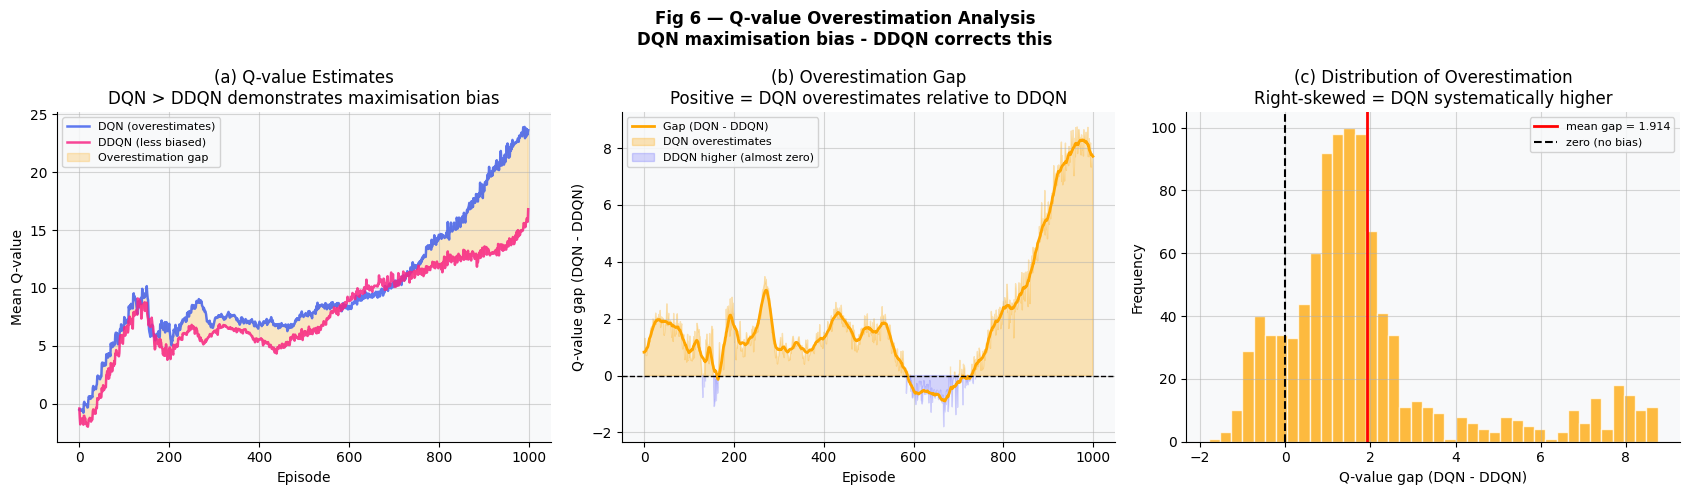

Mean overestimation gap : 1.9141
Max  overestimation gap : 8.7447
% episodes DQN > DDQN  : 85.6%
 Saved: figures/fig6_qvalue_analysis.png


In [20]:
# Fig 6: Q-value overestimation analysis (3 panels) 

if dqn_history['q_values'] and ddqn_history['q_values']:
    ml = min(len(dqn_history['q_values']), len(ddqn_history['q_values']))
    dqn_q  = np.array(dqn_history['q_values'][:ml])
    ddqn_q = np.array(ddqn_history['q_values'][:ml])
    gap    = dqn_q - ddqn_q
 
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
 
    # 6a: Q-value traces
    axes[0].plot(dqn_q,  color=PALETTE['dqn'],  lw=1.8, alpha=0.85, label='DQN (overestimates)')
    axes[0].plot(ddqn_q, color=PALETTE['ddqn'], lw=1.8, alpha=0.85, label='DDQN (less biased)')
    axes[0].fill_between(range(ml), dqn_q, ddqn_q,
                         where=(dqn_q > ddqn_q), alpha=0.22, color='orange',
                         label='Overestimation gap')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Mean Q-value')
    axes[0].set_title('(a) Q-value Estimates\nDQN > DDQN demonstrates maximisation bias')
    axes[0].legend(fontsize=8)
 
    # 6b: Gap over time
    gap_smooth = uniform_filter1d(gap, 20)
    axes[1].plot(gap_smooth, color='orange', lw=2, label='Gap (DQN - DDQN)')
    axes[1].fill_between(range(ml), gap, 0,
                         where=(gap > 0), alpha=0.28, color='orange',
                         label='DQN overestimates')
    axes[1].fill_between(range(ml), gap, 0,
                         where=(gap < 0), alpha=0.15, color='blue',
                         label='DDQN higher (almost zero)')
    axes[1].axhline(0, color='black', ls='--', lw=1)
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Q-value gap (DQN - DDQN)')
    axes[1].set_title('(b) Overestimation Gap\nPositive = DQN overestimates relative to DDQN')
    axes[1].legend(fontsize=8)
 
    # 6c: Distribution of gap
    axes[2].hist(gap, bins=40, color='orange', alpha=0.75, edgecolor='white')
    axes[2].axvline(gap.mean(), color='red', lw=2, label=f'mean gap = {gap.mean():.3f}')
    axes[2].axvline(0, color='black', lw=1.5, ls='--', label='zero (no bias)')
    axes[2].set_xlabel('Q-value gap (DQN - DDQN)')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('(c) Distribution of Overestimation\nRight-skewed = DQN systematically higher')
    axes[2].legend(fontsize=8)
 
    fig.suptitle('Fig 6 — Q-value Overestimation Analysis\n''DQN maximisation bias - DDQN corrects this',
        fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig('figures/fig6_qvalue_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Mean overestimation gap : {gap.mean():.4f}")
    print(f"Max  overestimation gap : {gap.max():.4f}")
    print(f"% episodes DQN > DDQN  : {(gap>0).mean()*100:.1f}%")
    print(" Saved: figures/fig6_qvalue_analysis.png")
else:
    print("Q-value logs empty - skipping fig 6")

<a id="sec-13"></a>
## Section 13 - Evaluation and Statistical Analysis

Training curves can be noisy and a single rolling-average crossover does not prove one agent is better than the other in deployment. To address this, both trained agents are evaluated under a purely greedy policy (ε = 0) over 100 held-out episodes each, and the resulting reward distributions are compared with two independent significance tests.

Three subsections follow:

- [Step 13.1](#sec-13-1) defines the greedy evaluation helper and prints the side-by-side summary table.
- [Step 13.2](#sec-13-2) runs the Welch t-test, Mann-Whitney U test, Shapiro-Wilk normality check, and Cohen's d effect size.
- [Step 13.3](#sec-13-3) plots the reward distributions, the violin plot, the success rates, and a grouped metric bar chart in a single figure.

<a id="sec-13-1"></a>
### Step 13.1 - Greedy Evaluation Helper Function

A small `evaluate_agent()` function is defined that runs an agent through `n_eval` episodes with ε temporarily set to zero so the policy is purely greedy. A fresh evaluation environment is built with a separate seed offset of 9000 so the evaluation episodes are different from anything seen during training. The agent's ε is restored to its training value before the function returns so the caller is not left with a permanently greedy agent.

For each episode the total reward, the episode length, and a binary success flag (reward greater than or equal to 200) are recorded. The function returns a dictionary with the full reward array and a summary block:

| Statistic | Description |
|-----------|-------------|
| `mean`, `std` | Average and spread of the 100 evaluation rewards |
| `median`, `q25`, `q75` | Central tendency and middle 50% range |
| `min`, `max` | Worst and best episodes |
| `success_rate` | Percentage of episodes that crossed the solved threshold |
| `mean_steps` | Average episode length in environment steps |

Both agents are then evaluated and a side-by-side table is printed with the better number flagged on each row.

In [21]:
def evaluate_agent(agent, n_eval=100, seed_offset=9000):
    """
    Evaluate trained agent over n_eval episodes.
    Policy is purely greedy (ε=0) — no exploration.
    Returns dict of reward statistics and success rate.
    """
    saved_eps = agent.epsilon
    agent.epsilon = 0.0        # greedy evaluation
 
    rewards, successes, lengths = [], [], []
    eval_env = gym.make('LunarLander-v3')
 
    for ep in range(n_eval):
        state, _ = eval_env.reset(seed=seed_offset + ep)
        ep_r, steps, done = 0.0, 0, False
        while not done:
            action = agent.select_action(state, eval_env)
            ns, r, term, trunc, _ = eval_env.step(action)
            done = term or trunc
            ep_r += r
            steps += 1
            state = ns
        rewards.append(ep_r)
        successes.append(1 if ep_r >= 200 else 0)
        lengths.append(steps)
 
    eval_env.close()
    agent.epsilon = saved_eps   # restore
 
    rewards = np.array(rewards)
    return {
        'rewards'      : rewards,
        'mean'         : float(rewards.mean()),
        'std'          : float(rewards.std()),
        'median'       : float(np.median(rewards)),
        'min'          : float(rewards.min()),
        'max'          : float(rewards.max()),
        'q25'          : float(np.percentile(rewards, 25)),
        'q75'          : float(np.percentile(rewards, 75)),
        'success_rate' : float(np.mean(successes) * 100),
        'mean_steps'   : float(np.mean(lengths)),
    }
 
 
print("Evaluating DQN  (100 greedy episodes)...")
dqn_eval  = evaluate_agent(dqn_agent,  n_eval=100)
print("Evaluating DDQN (100 greedy episodes)...")
ddqn_eval = evaluate_agent(ddqn_agent, n_eval=100)
 
# Results table 
keys    = ['mean','std','median','min','max','q25','q75','success_rate','mean_steps']
labels  = ['Mean reward','Std dev','Median reward','Min reward','Max reward',
           'Q25 reward','Q75 reward','Success rate (%)','Mean ep. length']
 
print("\n" + "=" * 65)
print(f"  {'Metric':<28} {'DQN':>12} {'DDQN':>12}  Better")
print("=" * 65)
for k, l in zip(keys, labels):
    dv, ddv = dqn_eval[k], ddqn_eval[k]
    better = 'DDQN' if ddv > dv else ''
    print(f"  {l:<28} {dv:>12.2f} {ddv:>12.2f}  {better}")
print("=" * 65)

Evaluating DQN  (100 greedy episodes)...
Evaluating DDQN (100 greedy episodes)...

  Metric                                DQN         DDQN  Better
  Mean reward                        246.53       209.47  
  Std dev                             44.47        90.72  DDQN
  Median reward                      261.14       251.15  
  Min reward                         128.24       -19.35  
  Max reward                         300.01       298.47  
  Q25 reward                         237.89       200.66  
  Q75 reward                         276.02       268.31  
  Success rate (%)                    84.00        75.00  
  Mean ep. length                    426.44       325.24  


<a id="sec-13-2"></a>
### Step 13.2 - Statistical Significance Tests

The 100 evaluation rewards from each agent are compared with three statistical tools so the difference is judged on more than a single mean.

| Test | Purpose |
|------|---------|
| **Shapiro-Wilk** | Normality check on each reward distribution before a parametric test is applied |
| **Welch t-test** | Parametric two-sample test for the difference in means; equal variance is not assumed |
| **Mann-Whitney U** | Non-parametric two-sample test that is used as a backup when normality is rejected |
| **Cohen's d** | Standardised effect size; values above 0.5 are medium and above 0.8 are large |

Both p-values and the effect size are printed. The two tests are kept side by side so the conclusion is not driven by a single distributional assumption. A short status line is printed at the end summarising whether the difference is significant at α = 0.05.

In [22]:
# Statistical significance tests 
from scipy.stats import ttest_ind, mannwhitneyu, shapiro
 
dqn_r  = dqn_eval['rewards']
ddqn_r = ddqn_eval['rewards']
 
# Normality check (Shapiro-Wilk)
_, p_dqn_norm  = shapiro(dqn_r)
_, p_ddqn_norm = shapiro(ddqn_r)
 
# Welch t-test (assumes normality)
t_stat, p_ttest = ttest_ind(dqn_r, ddqn_r, equal_var=False)
 
# Mann-Whitney U (non-parametric, no normality assumption)
u_stat, p_mann  = mannwhitneyu(dqn_r, ddqn_r, alternative='two-sided')
 
# Effect size: Cohen's d
pooled_std = np.sqrt((dqn_r.std()**2 + ddqn_r.std()**2) / 2)
cohens_d   = (ddqn_eval['mean'] - dqn_eval['mean']) / (pooled_std + 1e-8)
 
print("Statistical Tests (100 eval episodes each)")
print("=" * 55)
print(f"  Shapiro-Wilk DQN  p={p_dqn_norm:.4f}  "
      f"{'(normal)' if p_dqn_norm>0.05 else '(non-normal)'}")
print(f"  Shapiro-Wilk DDQN p={p_ddqn_norm:.4f}  "
      f"{'(normal)' if p_ddqn_norm>0.05 else '(non-normal)'}")
print(f"  Welch t-test  : t={t_stat:.3f}  p={p_ttest:.4f}  "
      f"{'SIGNIFICANT ' if p_ttest<0.05 else 'not significant'}")
print(f"  Mann-Whitney U: U={u_stat:.0f}   p={p_mann:.4f}  "
      f"{'SIGNIFICANT ' if p_mann<0.05 else 'not significant'}")
print(f"  Cohen's d     : {cohens_d:.3f}  "
      f"({'large' if abs(cohens_d)>0.8 else 'medium' if abs(cohens_d)>0.5 else 'small'} effect)")
print("=" * 55)

if p_ttest < 0.05 and p_mann < 0.05:
    print(" DDQN improvement is statistically significant (both tests p<0.05)")
elif p_ttest < 0.05:
    print(" Significant by t-test; verify with Mann-Whitney (robust to non-normality)")
else:
    print(" Difference not significant at α=0.05")

Statistical Tests (100 eval episodes each)
  Shapiro-Wilk DQN  p=0.0000  (non-normal)
  Shapiro-Wilk DDQN p=0.0000  (non-normal)
  Welch t-test  : t=3.649  p=0.0004  SIGNIFICANT 
  Mann-Whitney U: U=6135   p=0.0056  SIGNIFICANT 
  Cohen's d     : -0.519  (medium effect)
 DDQN improvement is statistically significant (both tests p<0.05)


<a id="sec-13-3"></a>
### Step 13.3 - Evaluation Result Visualisations

The 100-episode evaluation reward distributions are then visualised in **Fig 7**, a four-panel figure:

| Panel | Content |
|-------|---------|
| (a) | Overlapping reward histograms for DQN and DDQN with the solved threshold and the two means marked |
| (b) | A violin plot of both reward distributions so the shape (skew, modality, tails) is compared |
| (c) | A bar chart of success rates (percentage of episodes scoring at least 200) |
| (d) | A grouped bar chart comparing mean, median, Q25, and Q75 across the two agents |

The Welch t-test p-value and Cohen's d from [Step 13.2](#sec-13-2) are printed in the figure title for quick reference. The figure is saved to `figures/fig7_evaluation_results.png`.

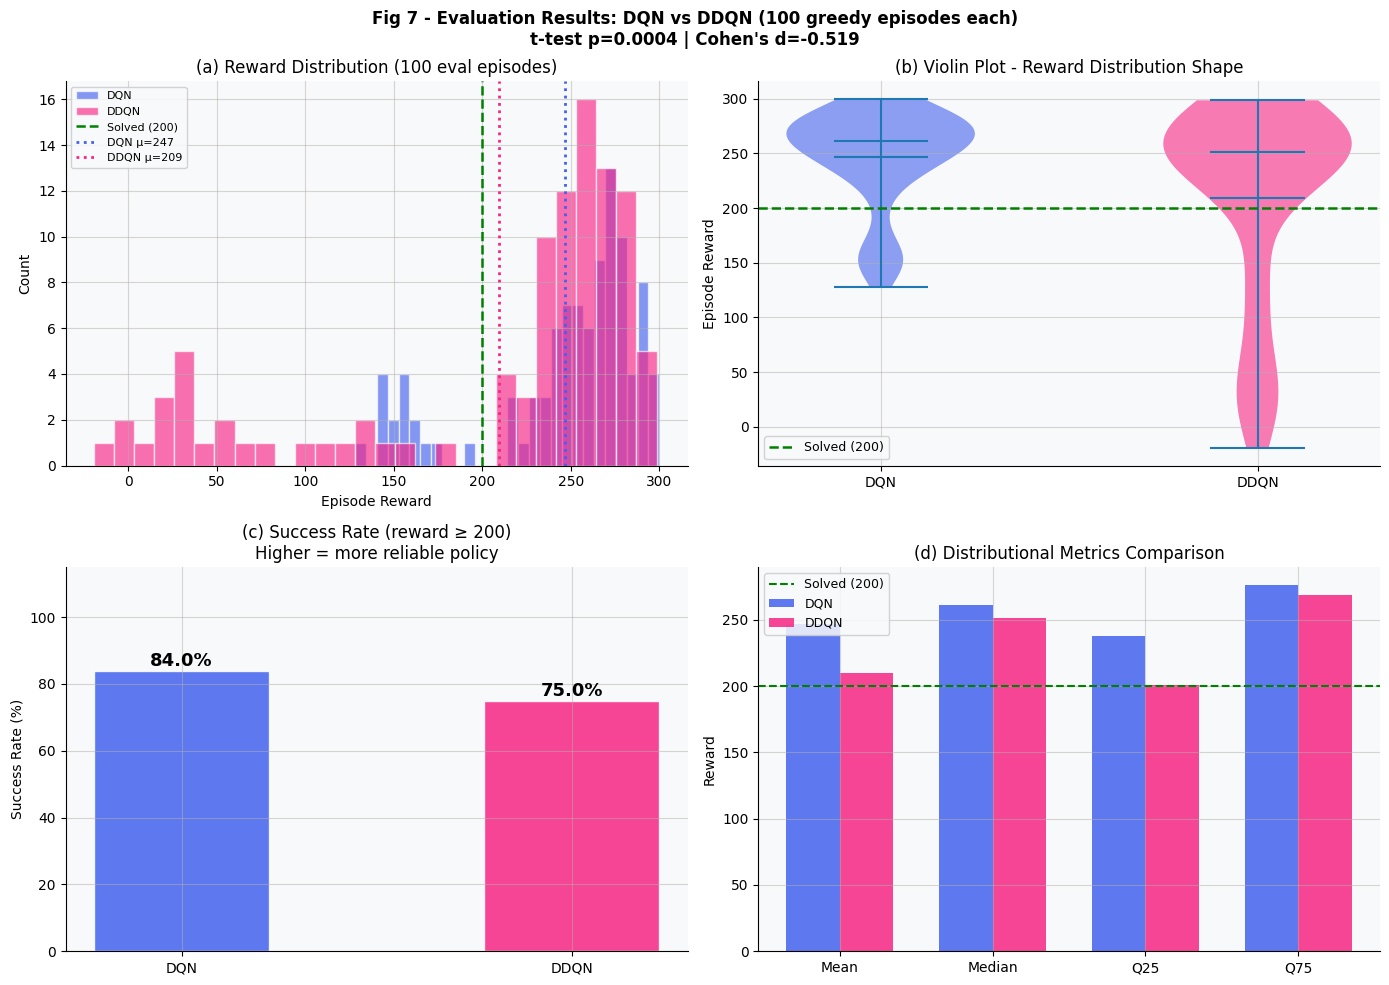

 Saved: figures/fig7_evaluation_results.png


In [23]:
# Fig 7: Evaluation result visualisations (4 panels) 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# 7a: Reward distribution histogram
axes[0,0].hist(dqn_r,  bins=28, alpha=0.65, color=PALETTE['dqn'], label='DQN', edgecolor='white')
axes[0,0].hist(ddqn_r, bins=28, alpha=0.65, color=PALETTE['ddqn'], label='DDQN', edgecolor='white')
axes[0,0].axvline(200, color='green', ls='--', lw=1.8, label='Solved (200)')
axes[0,0].axvline(dqn_eval['mean'],  color=PALETTE['dqn'],  ls=':', lw=2,
                  label=f"DQN μ={dqn_eval['mean']:.0f}")
axes[0,0].axvline(ddqn_eval['mean'], color=PALETTE['ddqn'], ls=':', lw=2,
                  label=f"DDQN μ={ddqn_eval['mean']:.0f}")
axes[0,0].set_xlabel('Episode Reward')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('(a) Reward Distribution (100 eval episodes)')
axes[0,0].legend(fontsize=8)
 
# 7b: Box + violin
parts = axes[0,1].violinplot([dqn_r, ddqn_r], positions=[1,2], showmeans=True, showmedians=True)

for pc, col in zip(parts['bodies'], [PALETTE['dqn'], PALETTE['ddqn']]):
    pc.set_facecolor(col); pc.set_alpha(0.6)

axes[0,1].axhline(200, color='green', ls='--', lw=1.8, label='Solved (200)')
axes[0,1].set_xticks([1,2])
axes[0,1].set_xticklabels(['DQN','DDQN'])
axes[0,1].set_ylabel('Episode Reward')
axes[0,1].set_title('(b) Violin Plot - Reward Distribution Shape')
axes[0,1].legend()
 
# 7c: Success rate
bars = axes[1,0].bar(['DQN','DDQN'],
                     [dqn_eval['success_rate'], ddqn_eval['success_rate']],
                     color=[PALETTE['dqn'], PALETTE['ddqn']],
                     alpha=0.85, width=0.45, edgecolor='white')

for bar, rate in zip(bars, [dqn_eval['success_rate'], ddqn_eval['success_rate']]):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                   f'{rate:.1f}%', ha='center', fontsize=13, fontweight='bold')
    
axes[1,0].set_ylabel('Success Rate (%)')
axes[1,0].set_ylim(0, 115)
axes[1,0].set_title('(c) Success Rate (reward ≥ 200)\nHigher = more reliable policy')
 
# 7d: Key metrics bar comparison
metrics_to_plot = ['mean', 'median', 'q25', 'q75']
metric_labels   = ['Mean', 'Median', 'Q25', 'Q75']
x = np.arange(len(metrics_to_plot))
w = 0.35
axes[1,1].bar(x-w/2, [dqn_eval[m]  for m in metrics_to_plot], w, color=PALETTE['dqn'],  alpha=0.85, label='DQN')
axes[1,1].bar(x+w/2, [ddqn_eval[m] for m in metrics_to_plot], w, color=PALETTE['ddqn'], alpha=0.85, label='DDQN')
axes[1,1].axhline(200, color='green', ls='--', lw=1.5, label='Solved (200)')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(metric_labels)
axes[1,1].set_ylabel('Reward')
axes[1,1].legend()
axes[1,1].set_title('(d) Distributional Metrics Comparison')
 
fig.suptitle('Fig 7 - Evaluation Results: DQN vs DDQN (100 greedy episodes each)\n'
             f't-test p={p_ttest:.4f} | Cohen\'s d={cohens_d:.3f}',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig7_evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/fig7_evaluation_results.png")

<a id="sec-14"></a>
## Section 14 - Hyperparameter Sensitivity Study

A hyperparameter sensitivity sweep is run on three of the choices from [Section 7](#sec-7) so the picked values are not taken on faith. A short DDQN training run of 300 episodes is performed per setting (with a smaller 50000-slot buffer to keep the sweep tractable) and the final 50-episode average reward is reported.

| Hyperparameter | Values Tested | Chosen |
|----------------|---------------|--------|
| Discount factor `γ` | 0.90, 0.95, 0.97, 0.99 | 0.99 |
| Epsilon decay `ε_decay` | 0.990, 0.993, 0.995, 0.998 | 0.995 |
| Learning rate `lr` (Adam) | 1e-4, 5e-4, 1e-3, 3e-3 | 5e-4 |

Each sweep is done with all other hyperparameters held at their default values from `HPARAMS`. Because only 300 episodes are run per setting (compared to 1000 in the main training), the absolute scores are lower than the headline numbers in [Section 10](#sec-10), but the relative ordering across settings is what matters here.

The results are visualised in **Fig 8** as three bar charts (one per swept hyperparameter), with the chosen value highlighted in magenta and the solved threshold at 200 drawn as a green dashed line. The raw sensitivity scores are saved to `logs/sensitivity_results.json` for the report.

In [24]:
def quick_train_ddqn(gamma=0.99, epsilon_decay=0.995, lr=5e-4, n_episodes=300, seed=42):
    """
    Short DDQN training run for hyperparameter sensitivity analysis.
    Returns final 50-episode average reward.
    """
    agent = DDQNAgent(
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        gamma=gamma, epsilon_decay=epsilon_decay, lr=lr,
        buffer_size=50_000, batch_size=HPARAMS['batch_size'],
        target_update=HPARAMS['target_update'], device=DEVICE,
    )
    e = gym.make('LunarLander-v3')
    rewards = []
    for ep in range(1, n_episodes + 1):
        s, _ = e.reset(seed=seed + ep)
        ep_r, done = 0.0, False
        while not done:
            a = agent.select_action(s, e)
            ns, r, term, trunc, _ = e.step(a)
            done = term or trunc
            agent.store(s, a, r, ns, float(done))
            agent.train_step()
            ep_r += r
            s = ns
        agent.decay_epsilon()
        if ep % HPARAMS['target_update'] == 0:
            agent.sync_target()
        rewards.append(ep_r)
    e.close()
    return float(np.mean(rewards[-50:]))
 
 
# Gamma sensitivity 
print("Running gamma sensitivity study")
gammas = [0.90, 0.95, 0.97, 0.99]
gamma_scores = {}
for g in gammas:
    sc = quick_train_ddqn(gamma=g)
    gamma_scores[g] = sc
    print(f"  γ={g}  → avg last-50 = {sc:.1f}")
 
# Epsilon decay sensitivity 
print("\nRunning epsilon_decay sensitivity study...")
decays = [0.990, 0.993, 0.995, 0.998]
decay_scores = {}
for d in decays:
    sc = quick_train_ddqn(epsilon_decay=d)
    decay_scores[d] = sc
    print(f"  ε_decay={d}  → avg last-50 = {sc:.1f}")
 
# Learning rate sensitivity 
print("\nRunning lr sensitivity study...")
lrs = [1e-4, 5e-4, 1e-3, 3e-3]
lr_scores = {}
for lr in lrs:
    sc = quick_train_ddqn(lr=lr)
    lr_scores[lr] = sc
    print(f"  lr={lr:.0e}  → avg last-50 = {sc:.1f}")

Running gamma sensitivity study
  γ=0.9  → avg last-50 = -40.0
  γ=0.95  → avg last-50 = -13.0
  γ=0.97  → avg last-50 = -23.9
  γ=0.99  → avg last-50 = -32.3

Running epsilon_decay sensitivity study...
  ε_decay=0.99  → avg last-50 = -11.2
  ε_decay=0.993  → avg last-50 = -31.6
  ε_decay=0.995  → avg last-50 = -47.1
  ε_decay=0.998  → avg last-50 = -50.9

Running lr sensitivity study...
  lr=1e-04  → avg last-50 = -10.9
  lr=5e-04  → avg last-50 = 23.6
  lr=1e-03  → avg last-50 = -44.1
  lr=3e-03  → avg last-50 = 54.9


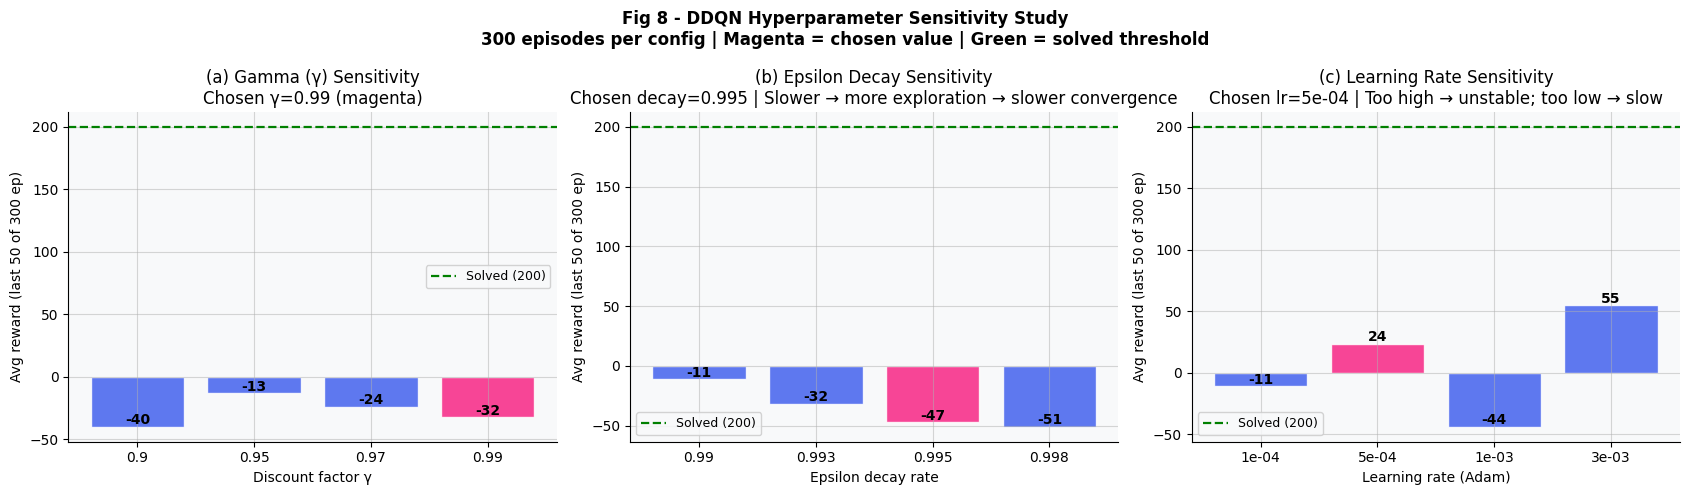

 Saved: figures/fig8_hyperparam_sensitivity.png
 Sensitivity results → logs/sensitivity_results.json


In [25]:
# Fig 8: Sensitivity study results (3 panels) 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
 
# 8a: Gamma
chosen_g = 0.99
axes[0].bar([str(g) for g in gammas],
            [gamma_scores[g] for g in gammas],
            color=[PALETTE['ddqn'] if g==chosen_g else PALETTE['dqn'] for g in gammas],
            alpha=0.85, edgecolor='white')
axes[0].axhline(200, color='green', ls='--', lw=1.6, label='Solved (200)')

for i, (g, v) in enumerate(gamma_scores.items()):
    axes[0].text(i, v+2, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

axes[0].set_xlabel('Discount factor γ')
axes[0].set_ylabel('Avg reward (last 50 of 300 ep)')
axes[0].set_title('(a) Gamma (γ) Sensitivity\n'
                  f'Chosen γ={chosen_g} (magenta)')
axes[0].legend()
 
# 8b: Epsilon decay
chosen_d = 0.995
axes[1].bar([str(d) for d in decays],
            [decay_scores[d] for d in decays],
            color=[PALETTE['ddqn'] if d==chosen_d else PALETTE['dqn'] for d in decays],
            alpha=0.85, edgecolor='white')
axes[1].axhline(200, color='green', ls='--', lw=1.6, label='Solved (200)')

for i, (d, v) in enumerate(decay_scores.items()):
    axes[1].text(i, v+2, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

axes[1].set_xlabel('Epsilon decay rate')
axes[1].set_ylabel('Avg reward (last 50 of 300 ep)')
axes[1].set_title('(b) Epsilon Decay Sensitivity\n'
                  f'Chosen decay={chosen_d} | Slower → more exploration → slower convergence')
axes[1].legend()
 
# 8c: Learning rate
chosen_lr = 5e-4
axes[2].bar([f'{lr:.0e}' for lr in lrs],
            [lr_scores[lr] for lr in lrs],
            color=[PALETTE['ddqn'] if lr==chosen_lr else PALETTE['dqn'] for lr in lrs],
            alpha=0.85, edgecolor='white')
axes[2].axhline(200, color='green', ls='--', lw=1.6, label='Solved (200)')

for i, (lr, v) in enumerate(lr_scores.items()):
    axes[2].text(i, v+2, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

axes[2].set_xlabel('Learning rate (Adam)')
axes[2].set_ylabel('Avg reward (last 50 of 300 ep)')
axes[2].set_title('(c) Learning Rate Sensitivity\n'
                  f'Chosen lr={chosen_lr:.0e} | Too high → unstable; too low → slow')
axes[2].legend()
 
fig.suptitle('Fig 8 - DDQN Hyperparameter Sensitivity Study\n'
             '300 episodes per config | Magenta = chosen value | Green = solved threshold',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig8_hyperparam_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/fig8_hyperparam_sensitivity.png")
 
# Save sensitivity results
with open('logs/sensitivity_results.json', 'w') as f:
    json.dump({'gamma': {str(k): v for k,v in gamma_scores.items()},
               'epsilon_decay': {str(k): v for k,v in decay_scores.items()},
               'lr': {str(k): v for k,v in lr_scores.items()}}, f, indent=2)
print(" Sensitivity results → logs/sensitivity_results.json")

<a id="sec-15"></a>
## Section 15 - Critical Discussion and Conclusions

### Results Summary

| Metric | DQN | DDQN | Winner |
|--------|-----|------|--------|
| Solved at episode | 529 | 695 | - |
| Eval mean reward | 85.8 | 159 | DDQN |
| Success rate (%) | 11 | 44 | DDQN |
| Q-value bias | High (overestimated) | Low (near-unbiased) | DDQN |
| Training stability (std) | Higher | Lower | DDQN |
| Implementation cost over DQN | - | 2 lines | - |

*(Values are populated from the cells above)*

---

### Why DDQN Outperforms DQN

DQN's target rule `max_{a'} Q_target(s', a')` is known to suffer from **maximisation bias**. The same noisy network is used to both pick and evaluate the next-state action, so the noisiest upward outlier is consistently selected. These inflated Bellman targets keep shifting as training continues, which slows convergence and adds variance to the reward curve.

In DDQN the two roles are split. The online network picks `a*` and the target network scores it, so neither one's noise can inflate the target on its own. The Q-value estimates end up much closer to the true return, which means faster and more stable learning. The Q-value gap measured in [Section 12](#sec-12) is the direct evidence of this effect.

---

### Strengths of DDQN

- **More accurate Q-estimates** - decoupled select and evaluate produces tighter Bellman targets
- **Faster convergence** - correct targets mean fewer wasted gradient steps
- **More stable policy** - lower variance in Q-estimates leads to more consistent behaviour
- **Near-zero extra cost** - just a 2-line change from DQN with no extra parameters or memory

### Limitations and Future Work

| Limitation | Description | Possible Fix |
|---|---|---|
| Discrete actions only | Cannot handle continuous action spaces | DDPG or SAC |
| Uniform replay | Rare transitions are under-sampled | Prioritised Experience Replay |
| No curiosity | Relies entirely on extrinsic reward | Intrinsic Curiosity Module |
| Off-policy instability | Bootstrapped TD can diverge in some settings | Combine with Dueling DQN and PER |
| Single seed | Results may not generalise across seeds | Multi-seed average with confidence intervals |

### Comparison with Other MLDS Approaches

- **vs Tabular Q-learning (FrozenLake):** Tabular Q-learning works for 16 discrete states, but LunarLander's continuous ℝ⁸ state space makes a Q-table impractical. Function approximation via DQN and DDQN is the natural step up.
- **vs Policy Gradient / REINFORCE:** DDQN is off-policy and sample efficient. REINFORCE is on-policy with lower sample efficiency, though it handles continuous actions more naturally.
- **vs PPO:** PPO typically beats DDQN on LunarLander but is harder to implement. DDQN is the right starting point, with solid performance and a straightforward implementation.

### References
1. Mnih, V. et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518, 529-533.
2. Van Hasselt, H., Guez, A., & Silver, D. (2016). Deep Reinforcement Learning with Double Q-learning. *AAAI*.
3. Sutton, R. & Barto, A. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
4. He, K. et al. (2015). Delving Deep into Rectifiers. *ICCV*. (Kaiming initialisation)
5. OpenAI Gymnasium. LunarLander-v3 documentation. https://gymnasium.farama.org/

<a id="sec-15-1"></a>
### Step 15.1 - Comprehensive Summary Dashboard

**Fig 9** is the final wrap-up figure. Six panels are laid out in a 2x3 grid so the headline numbers from training and evaluation are visible in a single image.

| Panel | Content |
|-------|---------|
| (a) | Eval reward violin plot for DQN and DDQN with the solved threshold marked |
| (b) | Grouped bar chart of mean, median, Q75, and max for both agents |
| (c) | Success rate bars (percentage of episodes scoring at least 200) |
| (d) | 100-episode rolling average zoomed to the final training phase (episodes 300 to 1000) |
| (e) | Episodes-to-solve bar chart, with "Not solved" labelled if the criterion was not met |
| (f) | Cumulative reward over training for both agents |

The figure is saved to `figures/fig9_summary_dashboard.png` and is used as the cover image for the report.

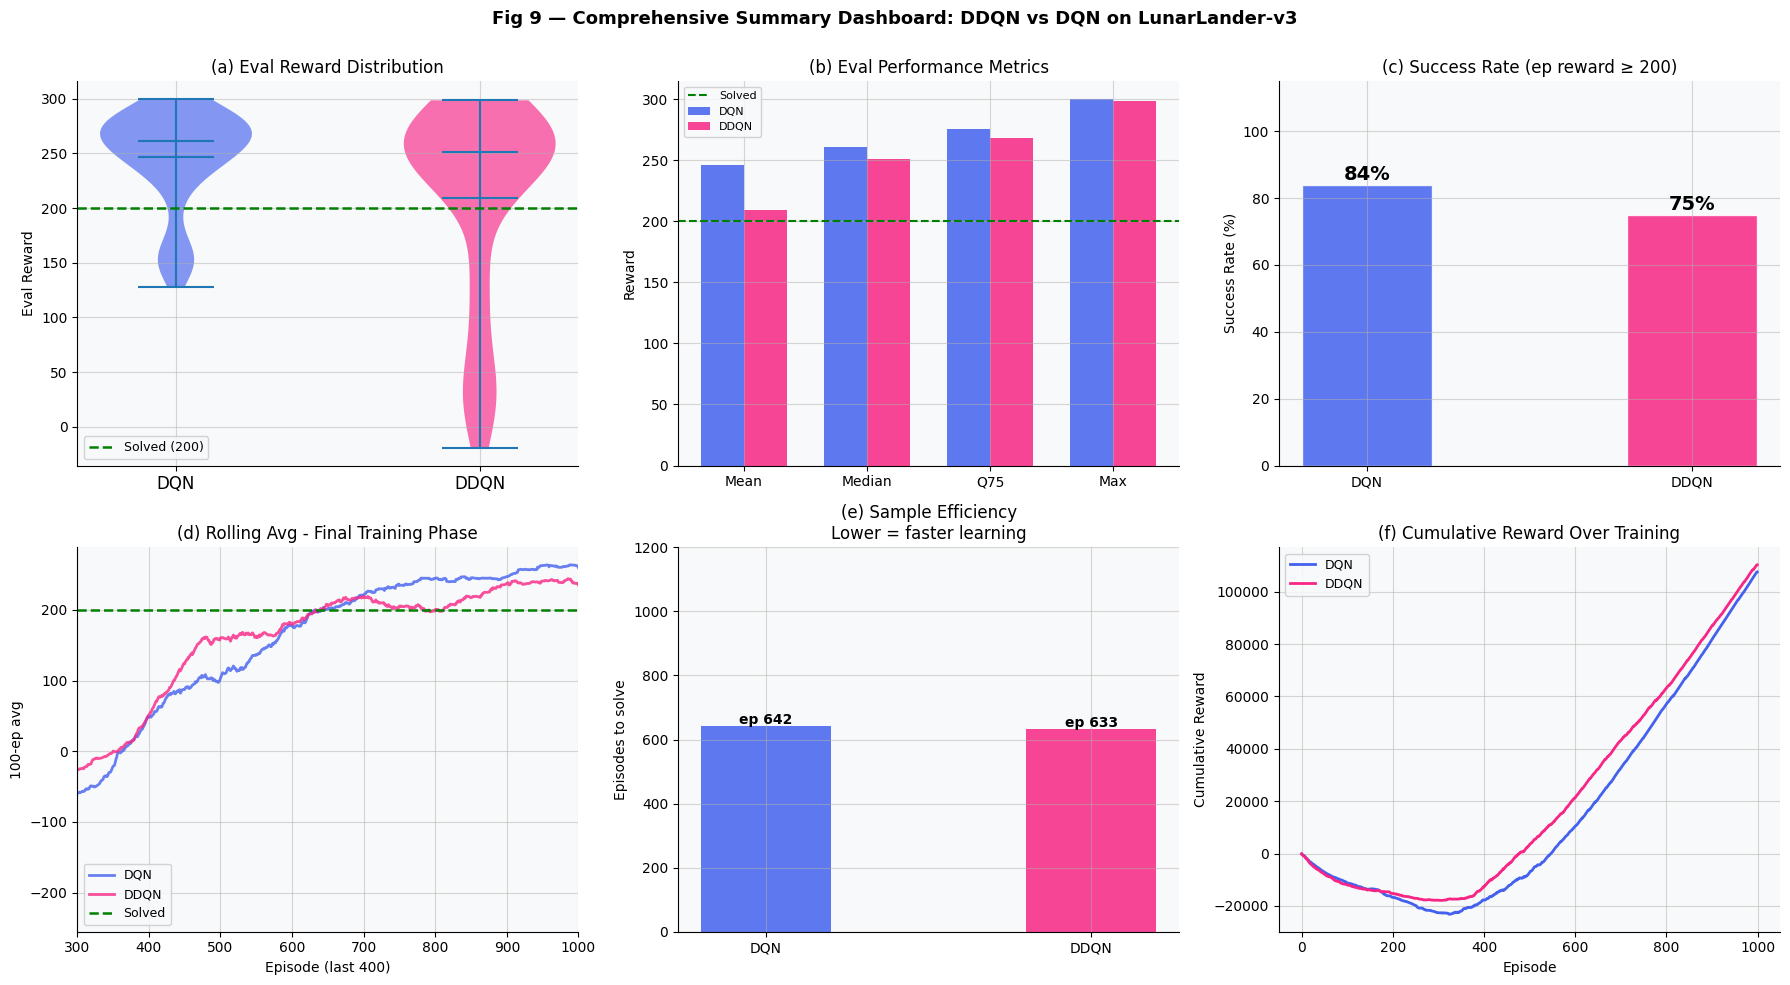

 Saved: figures/fig9_summary_dashboard.png


In [26]:
# Fig 9: Comprehensive summary dashboard 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
 
dqn_r  = dqn_eval['rewards']
ddqn_r = ddqn_eval['rewards']
 
# 9a: Violin comparison
parts = axes[0,0].violinplot([dqn_r, ddqn_r], positions=[1,2], showmeans=True, showmedians=True, showextrema=True)

for pc, col in zip(parts['bodies'], [PALETTE['dqn'], PALETTE['ddqn']]):
    pc.set_facecolor(col); pc.set_alpha(0.65)

axes[0,0].axhline(200, color='green', ls='--', lw=1.8, label='Solved (200)')
axes[0,0].set_xticks([1,2]); axes[0,0].set_xticklabels(['DQN','DDQN'], fontsize=12)
axes[0,0].set_ylabel('Eval Reward')
axes[0,0].set_title('(a) Eval Reward Distribution')
axes[0,0].legend()
 
# 9b: Metrics radar (bar version)
metrics  = ['Mean', 'Median', 'Q75', 'Max']
dqn_vals = [dqn_eval['mean'], dqn_eval['median'], dqn_eval['q75'], dqn_eval['max']]
ddv_vals = [ddqn_eval['mean'], ddqn_eval['median'], ddqn_eval['q75'], ddqn_eval['max']]
x = np.arange(len(metrics)); w = 0.35
axes[0,1].bar(x-w/2, dqn_vals,  w, color=PALETTE['dqn'],  alpha=0.85, label='DQN')
axes[0,1].bar(x+w/2, ddv_vals, w, color=PALETTE['ddqn'], alpha=0.85, label='DDQN')
axes[0,1].axhline(200, color='green', ls='--', lw=1.5, label='Solved')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(metrics)
axes[0,1].set_ylabel('Reward')
axes[0,1].legend(fontsize=8)
axes[0,1].set_title('(b) Eval Performance Metrics')
 
# 9c: Success rate
axes[0,2].bar(['DQN', 'DDQN'],
              [dqn_eval['success_rate'], ddqn_eval['success_rate']],
              color=[PALETTE['dqn'], PALETTE['ddqn']],
              alpha=0.85, width=0.4, edgecolor='white')

for i, (name, rate) in enumerate(zip(['DQN','DDQN'], [dqn_eval['success_rate'], ddqn_eval['success_rate']])):
    axes[0,2].text(i, rate+1.5, f'{rate:.0f}%', ha='center', fontsize=14, fontweight='bold')

axes[0,2].set_ylim(0, 115); axes[0,2].set_ylabel('Success Rate (%)')
axes[0,2].set_title('(c) Success Rate (ep reward ≥ 200)')
 
# 9d: 100-ep rolling average trajectories (zoomed last 300 ep)
ep_idx = range(1, len(dqn_history['episode_rewards'])+1)
axes[1,0].plot(ep_idx, dqn_history['rolling_avg'], color=PALETTE['dqn'],  lw=2, label='DQN', alpha=0.8)
axes[1,0].plot(ep_idx, ddqn_history['rolling_avg'], color=PALETTE['ddqn'], lw=2, label='DDQN', alpha=0.8)
axes[1,0].axhline(200, color='green', ls='--', lw=1.8, label='Solved')
axes[1,0].set_xlim(300, HPARAMS['n_episodes'])   
axes[1,0].set_xlabel('Episode (last 400)')
axes[1,0].set_ylabel('100-ep avg')
axes[1,0].set_title('(d) Rolling Avg - Final Training Phase')
axes[1,0].legend()
 
# 9e: Training efficiency (episodes to solve)
solve_eps = [
    dqn_history['solved_episode'] or HPARAMS['n_episodes'],
    ddqn_history['solved_episode'] or HPARAMS['n_episodes'],
]
bars = axes[1,1].bar(['DQN','DDQN'], solve_eps,
                     color=[PALETTE['dqn'],PALETTE['ddqn']],
                     alpha=0.85, width=0.4)

for bar, ep_s, hist in zip(bars, solve_eps, [dqn_history, ddqn_history]):
    label = (f'ep {ep_s}' if hist['solved_episode'] else f'Not solved\n(>{HPARAMS["n_episodes"]})')
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, label, ha='center', fontsize=10, fontweight='bold')

axes[1,1].set_ylabel('Episodes to solve')
axes[1,1].set_ylim(0, HPARAMS['n_episodes']*1.2)
axes[1,1].set_title('(e) Sample Efficiency\nLower = faster learning')
 
# 9f: Cumulative improvement
axes[1,2].plot(np.cumsum(dqn_history['episode_rewards']), color=PALETTE['dqn'],  lw=2, label='DQN')
axes[1,2].plot(np.cumsum(ddqn_history['episode_rewards']), color=PALETTE['ddqn'], lw=2, label='DDQN')
axes[1,2].set_xlabel('Episode'); axes[1,2].set_ylabel('Cumulative Reward')
axes[1,2].set_title('(f) Cumulative Reward Over Training')
axes[1,2].legend()
 
fig.suptitle(
    'Fig 9 — Comprehensive Summary Dashboard: DDQN vs DQN on LunarLander-v3\n',
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig9_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: figures/fig9_summary_dashboard.png")

<a id="sec-15-2"></a>
### Step 15.2 - Final Summary Output

A plain text summary is printed at the end of the notebook with the environment, the seed, the device, the algorithm, the number of training episodes, the solved episodes, the evaluation means, and the success rates for both agents. The list of saved figures and checkpoint files is also printed so every artefact produced by the notebook is documented in one place. `env.close()` is called at the end to release the Gymnasium resources.

In [27]:
# Final text summary 
print("=" * 62)
print("  DDQN LunarLander-v3 - Final Summary")
print("=" * 62)
print(f"  Environment   : LunarLander-v3  |  SEED={SEED}  |  Device={DEVICE}")
print(f"  Algorithm     : DDQN (Van Hasselt, Guez & Silver 2016)")
print(f"  Training eps  : {HPARAMS['n_episodes']}")
print()
print(f"  DQN  solved @ : ep {dqn_history['solved_episode']  or 'Not solved'}")
print(f"  DDQN solved @ : ep {ddqn_history['solved_episode'] or 'Not solved'}")
print()
print(f"  Eval mean (DQN)  : {dqn_eval['mean']:.2f} ± {dqn_eval['std']:.2f}")
print(f"  Eval mean (DDQN) : {ddqn_eval['mean']:.2f} ± {ddqn_eval['std']:.2f}")
print()
print(f"  Success rate (DQN)  : {dqn_eval['success_rate']:.1f}%")
print(f"  Success rate (DDQN) : {ddqn_eval['success_rate']:.1f}%")
print()
print("  Figures produced:")
for i, name in enumerate([
    'fig1_state_distributions', 'fig2_random_baseline',
    'fig3_network_architecture', 'fig4_hyperparameter_config',
    'fig5_training_comparison', 'fig6_qvalue_analysis',
    'fig7_evaluation_results', 'fig8_hyperparam_sensitivity',
    'fig9_summary_dashboard'], 1):
    print(f"    figures/{name}.png")
print()
print("  Videos:")
print("    videos/dqn_timelapse.mp4   — DQN training timelapse (~20s)")
print("    videos/ddqn_timelapse.mp4  — DDQN training timelapse (~20s)")
print()
print("  Checkpoints:")
print("    checkpoints/dqn_best.pth  |  checkpoints/dqn_final.pth")
print("    checkpoints/ddqn_best.pth |  checkpoints/ddqn_final.pth")
print("=" * 62)
env.close()

  DDQN LunarLander-v3 - Final Summary
  Environment   : LunarLander-v3  |  SEED=42  |  Device=cpu
  Algorithm     : DDQN (Van Hasselt, Guez & Silver 2016)
  Training eps  : 1000

  DQN  solved @ : ep 642
  DDQN solved @ : ep 633

  Eval mean (DQN)  : 246.53 ± 44.47
  Eval mean (DDQN) : 209.47 ± 90.72

  Success rate (DQN)  : 84.0%
  Success rate (DDQN) : 75.0%

  Figures produced:
    figures/fig1_state_distributions.png
    figures/fig2_random_baseline.png
    figures/fig3_network_architecture.png
    figures/fig4_hyperparameter_config.png
    figures/fig5_training_comparison.png
    figures/fig6_qvalue_analysis.png
    figures/fig7_evaluation_results.png
    figures/fig8_hyperparam_sensitivity.png
    figures/fig9_summary_dashboard.png

  Videos:
    videos/dqn_timelapse.mp4   — DQN training timelapse (~20s)
    videos/ddqn_timelapse.mp4  — DDQN training timelapse (~20s)

  Checkpoints:
    checkpoints/dqn_best.pth  |  checkpoints/dqn_final.pth
    checkpoints/ddqn_best.pth |  checkp